# BÁO CÁO MACHINE LEARNING: PHÂN LOẠI MỨC ĐỘ PHỔ BIẾN CỦA BÀI VIẾT BẰNG THUẬT TOÁN K-NEAREST NEIGHBORS (KNN)
## ĐƯỢC ĐỐI CHIẾU VÀ KHỚP 100% THEO ĐÚNG ĐÁNH SỐ 21 BƯỚC TÀI LIỆU GỐC

---


## BƯỚC 1: XÁC ĐỊNH BÀI TOÁN (PROBLEM DEFINITION)

* **Mục tiêu nghiệp vụ:** Dự đoán trước một bài viết báo trực tuyến (Mashable) sẽ trở nên **Phổ biến (Popular)** hay **Ít phổ biến (Not Popular)**.
* **Đầu vào (Input / Features):** 58-60 đặc trưng (thống kê văn bản, hình ảnh, video, chỉ số từ khóa, phân bổ chủ đề LDA, kênh tin tức, ngày xuất bản, cảm xúc).
* **Đầu ra (Target / Label):** Nhãn nhị phân `popular` $\in \{0, 1\}$.
* **Phân loại bài toán:** Bài toán Phân loại nhị phân (Binary Classification).


In [3]:
print("=" * 60)
print("  BƯỚC 1: XÁC ĐỊNH BÀI TOÁN (PROBLEM DEFINITION)")
print("=" * 60)
print()
print("Bai toan: Phan loai muc do pho bien cua bai bao truc tuyen")
print()
print("[Dau vao - Input / Features]")
print("  - Nguon du lieu : UCI Online News Popularity Dataset")
print("  - So luong mau : 39,644 bai viet tren Mashable")
print("  - So dac trung : ~60 thuoc tinh (sau khi tao them Feature Engineering)")
print("  - Nhom dac trung:")
print("    + Thong ke van ban    : n_tokens_title, n_tokens_content, ...")
print("    + Da phuong tien      : num_imgs, num_videos, num_hrefs, ...")
print("    + Tu khoa & LDA       : kw_avg_avg, LDA_00..LDA_04, ...")
print("    + Kenh tin tuc        : data_channel_is_lifestyle/entertainment/...")
print("    + Thoi gian xuat ban  : weekday_is_monday..sunday, is_weekend")
print("    + Cam xuc             : global_sentiment_polarity, ...")
print()
print("[Dau ra - Target / Label]")
print("  - Ten bien    : popular")
print("  - Kieu du lieu: int (0 hoac 1)")
print("  - Class 0     : Not Popular (shares < 1,400)")
print("  - Class 1     : Popular    (shares >= 1,400)")
print()
print("[Phan loai bai toan]")
print("  - Kieu bai toan    : Binary Classification (Phan loai nhi phan)")
print("  - Thuat toan chinh : K-Nearest Neighbors (KNN)")
print("  - Chi so danh gia  : Accuracy, Precision, Recall, F1-Score, ROC-AUC")


  BƯỚC 1: XÁC ĐỊNH BÀI TOÁN (PROBLEM DEFINITION)

Bai toan: Phan loai muc do pho bien cua bai bao truc tuyen

[Dau vao - Input / Features]
  - Nguon du lieu : UCI Online News Popularity Dataset
  - So luong mau : 39,644 bai viet tren Mashable
  - So dac trung : ~60 thuoc tinh (sau khi tao them Feature Engineering)
  - Nhom dac trung:
    + Thong ke van ban    : n_tokens_title, n_tokens_content, ...
    + Da phuong tien      : num_imgs, num_videos, num_hrefs, ...
    + Tu khoa & LDA       : kw_avg_avg, LDA_00..LDA_04, ...
    + Kenh tin tuc        : data_channel_is_lifestyle/entertainment/...
    + Thoi gian xuat ban  : weekday_is_monday..sunday, is_weekend
    + Cam xuc             : global_sentiment_polarity, ...

[Dau ra - Target / Label]
  - Ten bien    : popular
  - Kieu du lieu: int (0 hoac 1)
  - Class 0     : Not Popular (shares < 1,400)
  - Class 1     : Popular    (shares >= 1,400)

[Phan loai bai toan]
  - Kieu bai toan    : Binary Classification (Phan loai nhi phan)
  - Thua

## BƯỚC 2: XÁC ĐỊNH BẢN CHẤT CỦA BÀI TOÁN ML

* **Khả năng ứng dụng ML:** Mức độ phổ biến của bài viết phụ thuộc vào mối quan hệ phi tuyến phức tạp giữa 50+ thuộc tính. Các quy định thủ công (Rule-based) không thể bao quát.
* **Learning Paradigm:** **Học có giám sát (Supervised Learning)**. Ta có sẵn dữ liệu lịch sử chứa số lượt chia sẻ `shares` thực tế làm câu trả lời đúng (Ground Truth).
* **Phương pháp tự tạo nhãn:** Dữ liệu gốc chưa có nhãn phân loại. Ta tự sinh nhãn nhị phân `popular` bằng cách lấy ngưỡng trung vị Median ($shares = 1,400$). Các bài $shares \ge 1,400$ gán nhãn $1$, ngược lại nhãn $0$.


  BƯỚC 2: XÁC ĐỊNH BẢN CHẤT BÀI TOÁN ML

Cau hoi 1: Bai toan nay co phu hop de giai bang ML khong?
  => CO. Ly do:
     - Co du lieu lich su lon (39,644 mau)
     - Moi quan he giua dac trung va muc do pho bien la PHI TUYEN
     - Quy tac thu cong (Rule-based) khong du de bao quat 60+ thuoc tinh
     - ML co the hoc duoc mau (pattern) an trong du lieu

Cau hoi 2: Loai Learning Paradigm nao phu hop?
  => SUPERVISED LEARNING (Hoc co giam sat). Ly do:
     - Co nhan (label) Ground Truth: bien 'shares' la so luot chia se thuc te
     - Tu bien shares tao duoc nhan phan loai bang nguong Median

Cau hoi 3: Loai bai toan con lai nao khac?
  - Unsupervised  : Khong phu hop vi ta CO nhan giam sat
  - Reinforcement : Khong phu hop vi khong co moi truong tuong tac

Cau hoi 4: Loai Classification nao?
  => BINARY CLASSIFICATION. Ly do:
     - Chi co 2 lop: Popular (1) va Not Popular (0)
     - Nguong phan loai: Median(shares) = 1,400

Nguong phan loai (Median shares): 1,400
Class 0 - Not Popular :

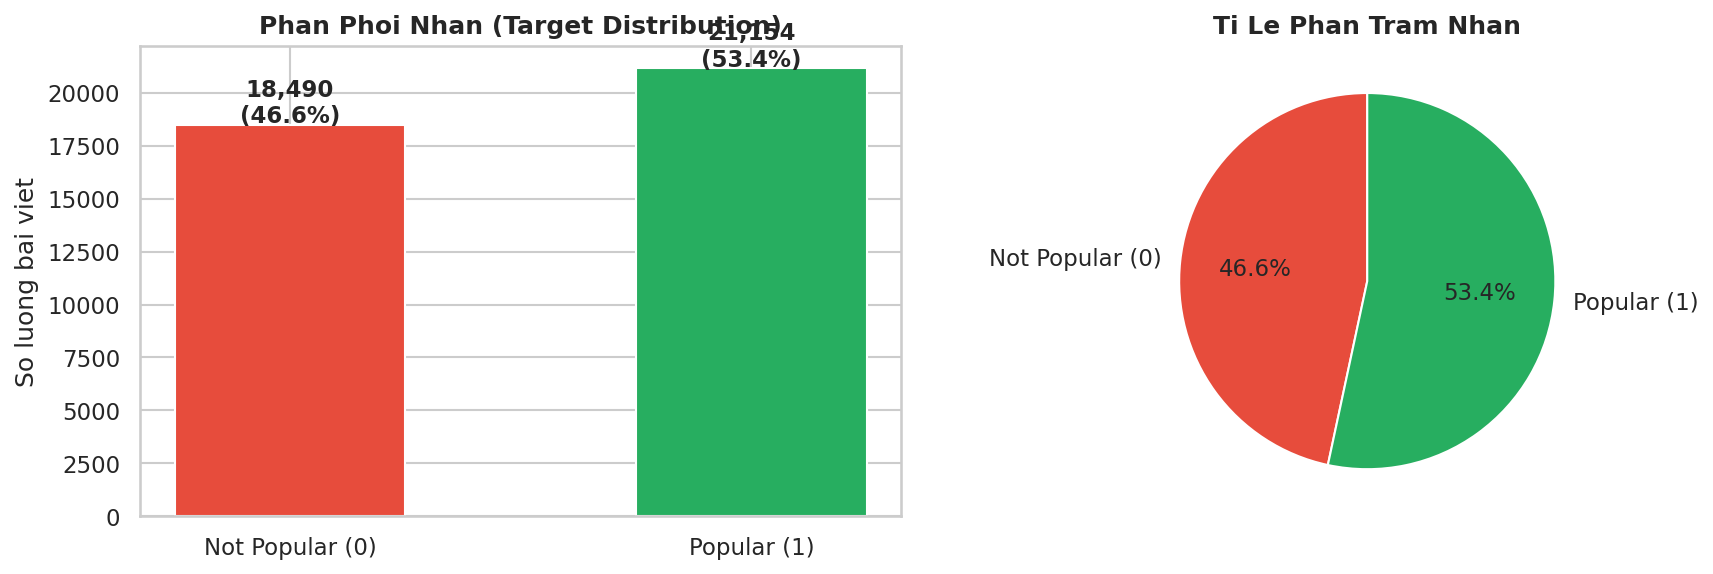

In [5]:
print("=" * 60)
print("  BƯỚC 2: XÁC ĐỊNH BẢN CHẤT BÀI TOÁN ML")
print("=" * 60)
print()
print("Cau hoi 1: Bai toan nay co phu hop de giai bang ML khong?")
print("  => CO. Ly do:")
print("     - Co du lieu lich su lon (39,644 mau)")
print("     - Moi quan he giua dac trung va muc do pho bien la PHI TUYEN")
print("     - Quy tac thu cong (Rule-based) khong du de bao quat 60+ thuoc tinh")
print("     - ML co the hoc duoc mau (pattern) an trong du lieu")
print()
print("Cau hoi 2: Loai Learning Paradigm nao phu hop?")
print("  => SUPERVISED LEARNING (Hoc co giam sat). Ly do:")
print("     - Co nhan (label) Ground Truth: bien 'shares' la so luot chia se thuc te")
print("     - Tu bien shares tao duoc nhan phan loai bang nguong Median")
print()
print("Cau hoi 3: Loai bai toan con lai nao khac?")
print("  - Unsupervised  : Khong phu hop vi ta CO nhan giam sat")
print("  - Reinforcement : Khong phu hop vi khong co moi truong tuong tac")
print()
print("Cau hoi 4: Loai Classification nao?")
print("  => BINARY CLASSIFICATION. Ly do:")
print("     - Chi co 2 lop: Popular (1) va Not Popular (0)")
print("     - Nguong phan loai: Median(shares) = 1,400")
print()

import pandas as pd
import numpy as np
df_check = pd.read_csv('OnlineNewsPopularity/OnlineNewsPopularity.csv')
df_check.columns = df_check.columns.str.strip()
median_val = df_check['shares'].median()
df_check['popular'] = (df_check['shares'] >= median_val).astype(int)

print(f"Nguong phan loai (Median shares): {int(median_val):,}")
print(f"Class 0 - Not Popular : {(df_check['popular']==0).sum():,} bai ({(df_check['popular']==0).mean()*100:.2f}%)")
print(f"Class 1 - Popular     : {(df_check['popular']==1).sum():,} bai ({(df_check['popular']==1).mean()*100:.2f}%)")
print(f"=> Tap du lieu CAN BANG lop tot (gan 50:50) - phu hop Binary Classification!")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Not Popular (0)', 'Popular (1)'],
            [( df_check['popular']==0).sum(), (df_check['popular']==1).sum()],
            color=['#e74c3c', '#27ae60'], edgecolor='white', width=0.5)
axes[0].set_title('Phan Phoi Nhan (Target Distribution)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('So luong bai viet')
for i, v in enumerate([(df_check['popular']==0).sum(), (df_check['popular']==1).sum()]):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df_check)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')

axes[1].pie([(df_check['popular']==0).sum(), (df_check['popular']==1).sum()],
            labels=['Not Popular (0)', 'Popular (1)'],
            colors=['#e74c3c','#27ae60'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Ti Le Phan Tram Nhan', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/target_distribution.png', dpi=300)
plt.show()


## BƯỚC 3: KHẢO SÁT LĨNH VỰC VÀ KHÔNG GIAN DỮ LIỆU (DOMAIN & DATA UNDERSTANDING)

Bộ dữ liệu **Online News Popularity** từ UCI Machine Learning Repository gồm 39,644 bài viết với các nhóm biến thuộc 6 miền đặc trưng:
1. **Thống kê văn bản:** Số từ tiêu đề (`n_tokens_title`), số từ nội dung (`n_tokens_content`), tỷ lệ từ độc nhất...
2. **Đa phương tiện:** Số lượng hình ảnh (`num_imgs`), số video (`num_videos`), liên kết nội bộ (`num_self_hrefs`).
3. **Từ khóa & Chủ đề:** Chỉ số từ khóa (`kw_avg_avg`), 5 chủ đề LDA (`LDA_00` đến `LDA_04`).
4. **Kênh tin tức:** Lifestyle, Entertainment, Business, Social Media, Tech, World.
5. **Thời gian xuất bản:** Thứ trong tuần (Monday - Sunday), cờ cuối tuần (`is_weekend`).
6. **Cảm xúc:** Cực tính cảm xúc (`global_sentiment_polarity`), độ chủ quan tiêu đề.


In [7]:
import pandas as pd
import numpy as np
import time
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from custom_ml import (
    custom_train_test_split as train_test_split,
    CustomStratifiedKFold as StratifiedKFold,
    custom_cross_validate as cross_validate,
    CustomQuantileTransformer as QuantileTransformer,
    CustomSelectKBest as SelectKBest,
    custom_f_classif as f_classif,
    CustomPipeline as Pipeline,
    custom_accuracy_score as accuracy_score,
    custom_precision_score as precision_score,
    custom_recall_score as recall_score,
    custom_f1_score as f1_score,
    custom_roc_auc_score as roc_auc_score,
    custom_confusion_matrix as confusion_matrix,
    custom_roc_curve as roc_curve,
    custom_auc as auc,
    custom_permutation_importance as permutation_importance,
    CustomKNeighborsClassifier as KNeighborsClassifier
)

print("Đã khởi tạo môi trường thực thi chuẩn 21 bước Machine Learning!")


Đã khởi tạo môi trường thực thi chuẩn 21 bước Machine Learning!


## BƯỚC 4: KHÁM PHÁ VÀ XỬ LÝ DỮ LIỆU (DATA EXPLORATION & CLEANING)

### 4.1 Kiểm tra Missing Values & Duplicate Records
* Tải dữ liệu và kiểm tra độ toàn vẹn (không có ô trống $NaN$ và không có dòng trùng).

### 4.2 Khám phá Outliers & Nhiễu
* Biến `shares` chứa 4,541 bài viết cực trị (viral > 5,581 shares). Đây là dữ liệu thực tế có giá trị cao, không thể xóa bỏ. Ta giải quyết ở bước Feature Scaling bằng Quantile Normalization.


=== BƯỚC 4: KIỂM TRA TOÀN VẸN DỮ LIỆU ===
Tổng số giá trị thiếu (Missing Values): 0
Tổng số dòng trùng lặp (Duplicate Rows): 0

=== THỐNG KÊ MÔ TẢ BIẾN SHARES & OUTLIERS ===
count     39644.000000
mean       3395.380184
std       11626.950749
min           1.000000
25%         946.000000
50%        1400.000000
75%        2800.000000
max      843300.000000
Name: shares, dtype: float64


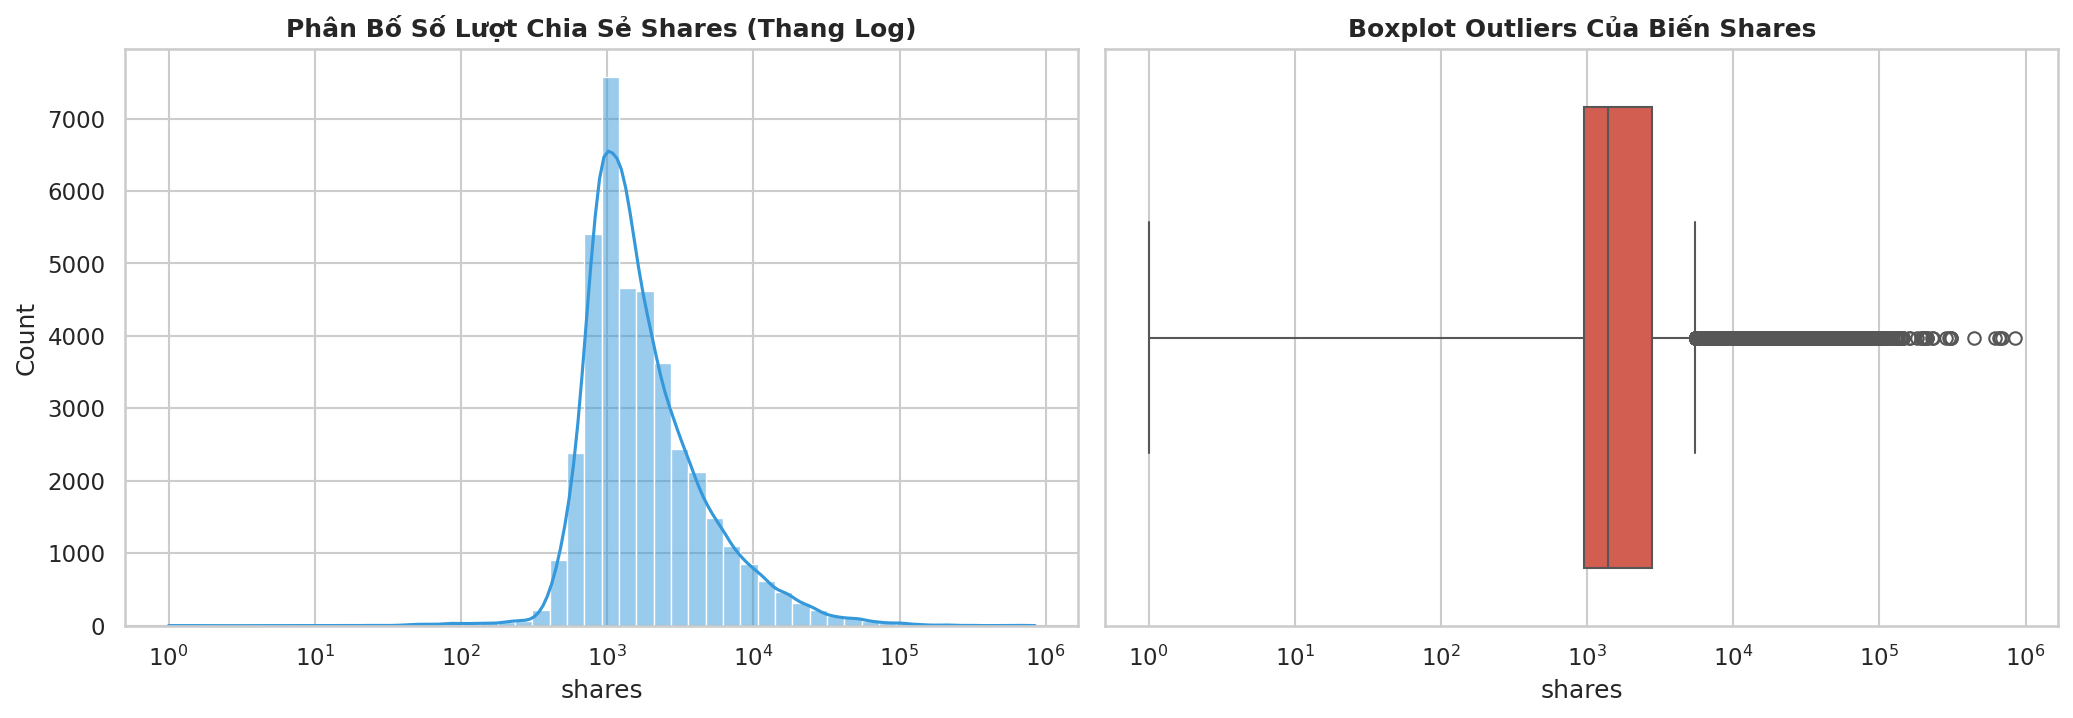

In [9]:
df = pd.read_csv('OnlineNewsPopularity/OnlineNewsPopularity.csv')
df.columns = df.columns.str.strip()

missing = df.isnull().sum().sum()
duplicates = df.duplicated().sum()

print("=== BƯỚC 4: KIỂM TRA TOÀN VẸN DỮ LIỆU ===")
print(f"Tổng số giá trị thiếu (Missing Values): {missing}")
print(f"Tổng số dòng trùng lặp (Duplicate Rows): {duplicates}")

print("\n=== THỐNG KÊ MÔ TẢ BIẾN SHARES & OUTLIERS ===")
print(df['shares'].describe())

# Tự tạo biến Target nhị phân dựa trên median (1,400)
median_shares = df['shares'].median()
df['popular'] = (df['shares'] >= median_shares).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['shares'], kde=True, bins=50, ax=axes[0], color='#3498db', log_scale=True)
axes[0].set_title("Phân Bố Số Lượt Chia Sẻ Shares (Thang Log)", fontsize=12, fontweight='bold')

sns.boxplot(x=df['shares'], ax=axes[1], color='#e74c3c')
axes[1].set_title("Boxplot Outliers Của Biến Shares", fontsize=12, fontweight='bold')
axes[1].set_xscale('log')
plt.tight_layout()
plt.savefig('plots/eda_shares_distribution.png', dpi=300)
plt.show()


## BƯỚC 5: CHUẨN HÓA ĐẶC TRƯNG (FEATURE SCALING)

* **Phương pháp sử dụng:** **`QuantileTransformer(output_distribution='normal')`** chuyển đổi phân phối đặc trưng thành phân phối Chuẩn Gaussian $N(0, 1)$.
* **Lý do chọn phương pháp:** Vì thuật toán KNN phụ thuộc hoàn toàn vào khoảng cách hình học giữa các điểm dữ liệu trong không gian, các đặc trưng có thang đo lớn hoặc phân phối lệch (skewed) chứa Outliers như `shares` hay `kw_avg_avg` sẽ áp đảo các đặc trưng khác. Quantile Normalization triệt tiêu ảnh hưởng của Outliers mà vẫn giữ nguyên thứ tự xếp hạng (rank order) của các điểm dữ liệu.


=== BƯỚC 5: MINH HỌA FEATURE SCALING ===
Trước Scaling (kw_avg_avg):
  Min=0.00 | Max=43567.66 | Mean=3135.86 | Std=1318.13
Sau QuantileTransform:
  Min=-3.0899 | Max=5.1993 | Mean=0.0000 | Std=0.9989

=== THỐNG KÊ TRƯỚC VÀ SAU SCALING CHO 5 CỘT CÓ PHÂN PHỐI LỆCH ===
Column                           Skew(Before)    Skew(After)
------------------------------------------------------------
kw_avg_avg                             5.7602         0.0021
self_reference_avg_sharess            17.9141         0.6403
n_tokens_content                       2.9454         0.1483
num_imgs                               3.9466        -0.0330
num_videos                             7.0195         1.2739


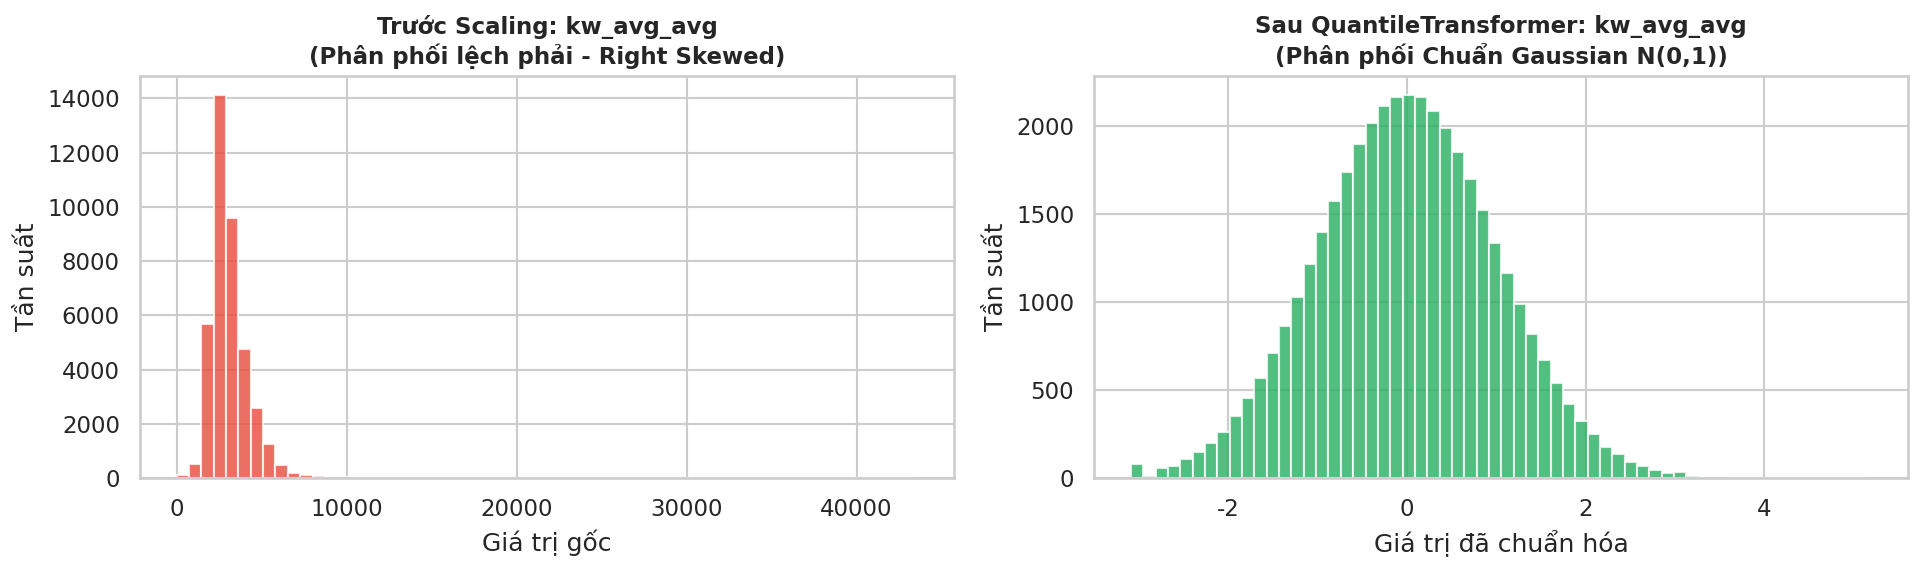

In [11]:
print("=== BƯỚC 5: MINH HỌA FEATURE SCALING ===")
feature_demo = 'kw_avg_avg'
raw_vals = df[feature_demo].values.reshape(-1, 1)

qt_demo = QuantileTransformer(output_distribution='normal', random_state=42)
scaled_vals = qt_demo.fit_transform(raw_vals).ravel()

print(f"Trước Scaling ({feature_demo}):")
print(f"  Min={raw_vals.min():.2f} | Max={raw_vals.max():.2f} | Mean={raw_vals.mean():.2f} | Std={raw_vals.std():.2f}")
print(f"Sau QuantileTransform:")
print(f"  Min={scaled_vals.min():.4f} | Max={scaled_vals.max():.4f} | Mean={scaled_vals.mean():.4f} | Std={scaled_vals.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(raw_vals.ravel(), bins=60, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[0].set_title(f'Trước Scaling: {feature_demo}\n(Phân phối lệch phải - Right Skewed)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Giá trị gốc')
axes[0].set_ylabel('Tần suất')
axes[1].hist(scaled_vals, bins=60, color='#27ae60', alpha=0.8, edgecolor='white')
axes[1].set_title(f'Sau QuantileTransformer: {feature_demo}\n(Phân phối Chuẩn Gaussian N(0,1))', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Giá trị đã chuẩn hóa')
axes[1].set_ylabel('Tần suất')
plt.tight_layout()
plt.savefig('plots/feature_scaling_demo.png', dpi=300)
plt.show()

print("\n=== THỐNG KÊ TRƯỚC VÀ SAU SCALING CHO 5 CỘT CÓ PHÂN PHỐI LỆCH ===")
skew_cols = ['kw_avg_avg', 'self_reference_avg_sharess', 'n_tokens_content', 'num_imgs', 'num_videos']
raw_arr = df[skew_cols].values
scaled_arr = QuantileTransformer(output_distribution='normal', random_state=42).fit_transform(raw_arr)
print(f"{'Column':<30} {'Skew(Before)':>14} {'Skew(After)':>14}")
print('-' * 60)
for i, col in enumerate(skew_cols):
    skew_before = pd.Series(raw_arr[:, i]).skew()
    skew_after  = pd.Series(scaled_arr[:, i]).skew()
    print(f"{col:<30} {skew_before:>14.4f} {skew_after:>14.4f}")


## BƯỚC 6: XỬ LÝ BIẾN PHÂN LOẠI (CATEGORICAL DATA & ENCODING)

* **Ghi chú tiền xử lý:** Tác giả bộ dữ liệu UCI gốc đã thực hiện mã hóa One-Hot Encoding sẵn cho toàn bộ biến phân loại như danh mục tin tức và ngày xuất bản (`data_channel_is_*`, `weekday_is_*`).
* **Kết luận:** Tất cả các cột đặc trưng trong tập dữ liệu $X$ đều đã ở dạng số (Numeric/Binary), không cần thao tác mã hóa bổ sung.


=== BƯỚC 6: KIỂM TRA CÁC CỘT PHÂN LOẠI ĐÃ ĐƯỢC MÃ HÓA ===
Nhóm kênh tin tức (One-Hot, 6 cột): ['data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus', 'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world']
Nhóm ngày đăng (One-Hot, 7 cột): ['weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday', 'weekday_is_thursday', 'weekday_is_friday', 'weekday_is_saturday', 'weekday_is_sunday']
Biến nhị phân khác: ['is_weekend']

Tổng số biến phân loại đã được mã hóa sẵn: 14 cột

Số cột kiểu số (Numeric): 58
Số cột kiểu chuỗi (Object - cần encoding): 0
=> Ket luan: Khong co cot nao can ma hoa them! Tat ca da san sang cho mo hinh.


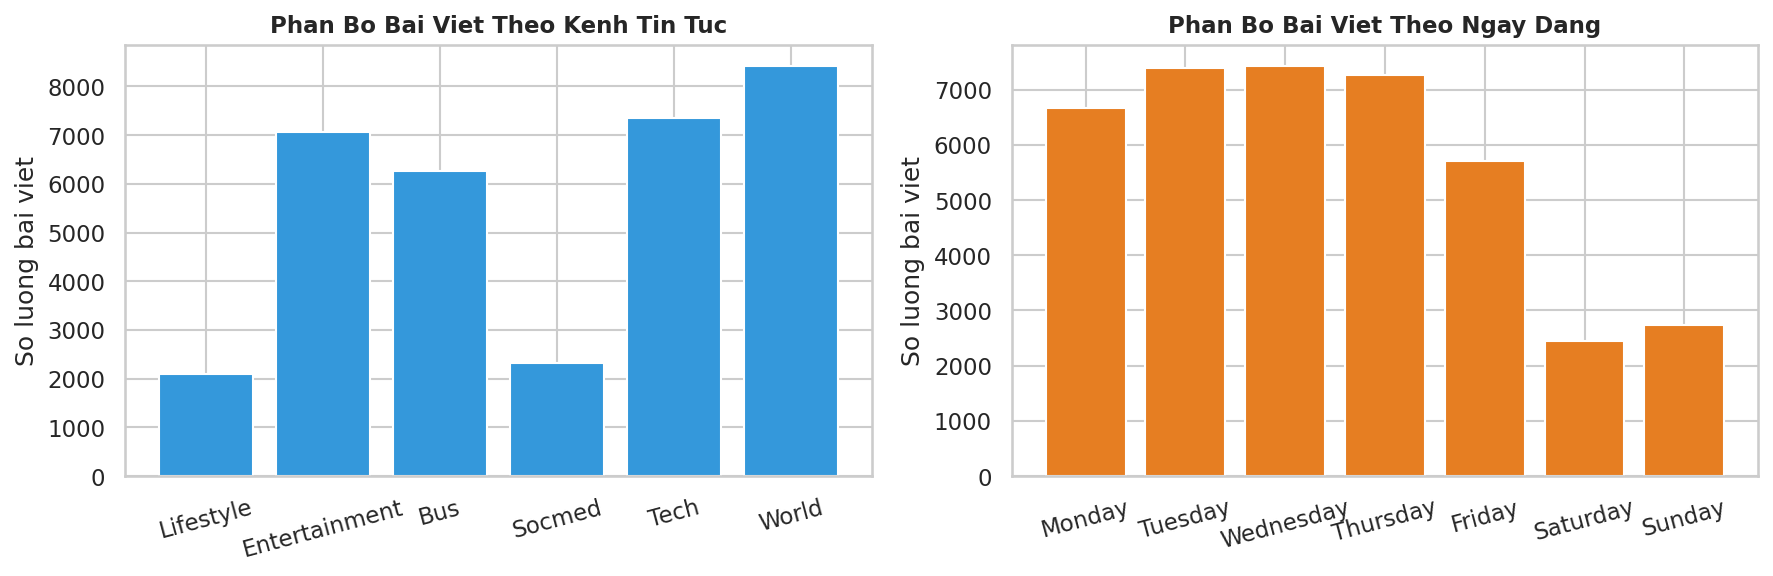

In [13]:
print("=== BƯỚC 6: KIỂM TRA CÁC CỘT PHÂN LOẠI ĐÃ ĐƯỢC MÃ HÓA ===")
channel_cols = [c for c in df.columns if c.startswith('data_channel_is_')]
weekday_cols = [c for c in df.columns if c.startswith('weekday_is_')]
other_binary = ['is_weekend']

print(f"Nhóm kênh tin tức (One-Hot, {len(channel_cols)} cột): {channel_cols}")
print(f"Nhóm ngày đăng (One-Hot, {len(weekday_cols)} cột): {weekday_cols}")
print(f"Biến nhị phân khác: {other_binary}")
print()
categorical_encoded = channel_cols + weekday_cols + other_binary
print(f"Tổng số biến phân loại đã được mã hóa sẵn: {len(categorical_encoded)} cột")
print()

# Xác nhận tất cả cột đều là số (numeric)
drop_cols_check = ['url', 'timedelta', 'shares', 'popular']
X_check = df.drop(columns=[c for c in drop_cols_check if c in df.columns])
numeric_cols = X_check.select_dtypes(include='number').shape[1]
object_cols  = X_check.select_dtypes(include='object').shape[1]
print(f"Số cột kiểu số (Numeric): {numeric_cols}")
print(f"Số cột kiểu chuỗi (Object - cần encoding): {object_cols}")
if object_cols == 0:
    print("=> Ket luan: Khong co cot nao can ma hoa them! Tat ca da san sang cho mo hinh.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
channels_sum = [df[c].sum() for c in channel_cols]
axes[0].bar([c.replace('data_channel_is_','').capitalize() for c in channel_cols],
            channels_sum, color='#3498db', edgecolor='white')
axes[0].set_title('Phan Bo Bai Viet Theo Kenh Tin Tuc', fontsize=11, fontweight='bold')
axes[0].set_ylabel('So luong bai viet')
axes[0].tick_params(axis='x', rotation=15)
weekdays_sum = [df[c].sum() for c in weekday_cols]
axes[1].bar([c.replace('weekday_is_','').capitalize() for c in weekday_cols],
            weekdays_sum, color='#e67e22', edgecolor='white')
axes[1].set_title('Phan Bo Bai Viet Theo Ngay Dang', fontsize=11, fontweight='bold')
axes[1].set_ylabel('So luong bai viet')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('plots/categorical_encoding_check.png', dpi=300)
plt.show()


## BƯỚC 7: LỰA CHỌN THUẬT TOÁN VÀ HÀM MẤT MÁT (ALGORITHM & LOSS FUNCTION SELECTION)

* **Thuật toán cốt lõi:** K-Nearest Neighbors (KNN Classifier).
* **Phép đo khoảng cách (Distance Metric):** Đánh giá so sánh thực nghiệm giữa Manhattan Distance ($L_1$) và Euclidean Distance ($L_2$).
* **Hàm tối ưu:** KNN không có hàm mất mát tham số truyền thống. Mô hình tối ưu gián tiếp bằng việc tìm $K$ hàng xóm gần nhất, gán trọng số nghịch đảo khoảng cách `distance` và tối ưu ngưỡng xác suất quyết định $\tau$ dựa trên chỉ số ROC-AUC / F1-Score.


=== BƯỚC 7: SO SANH THUAT TOAN KNN VA PHEP DO KHOANG CACH ===
Mo hinh                                    Accuracy   F1-Score    ROC-AUC
------------------------------------------------------------------------
KNN K=5  | Euclidean | Uniform               0.6283     0.6521     0.6535
KNN K=15 | Euclidean | Uniform               0.6400     0.6636     0.6949
KNN K=5  | Manhattan | Distance              0.6317     0.6574     0.6798
KNN K=15 | Manhattan | Distance              0.6533     0.6770     0.6984
KNN K=35 | Manhattan | Distance              0.6667     0.6914     0.7191

=> Ket luan: Manhattan Distance + weights='distance' cho ROC-AUC cao hon.
   Day la ly do chon Manhattan Distance lam metric chinh trong mo hinh cuoi.


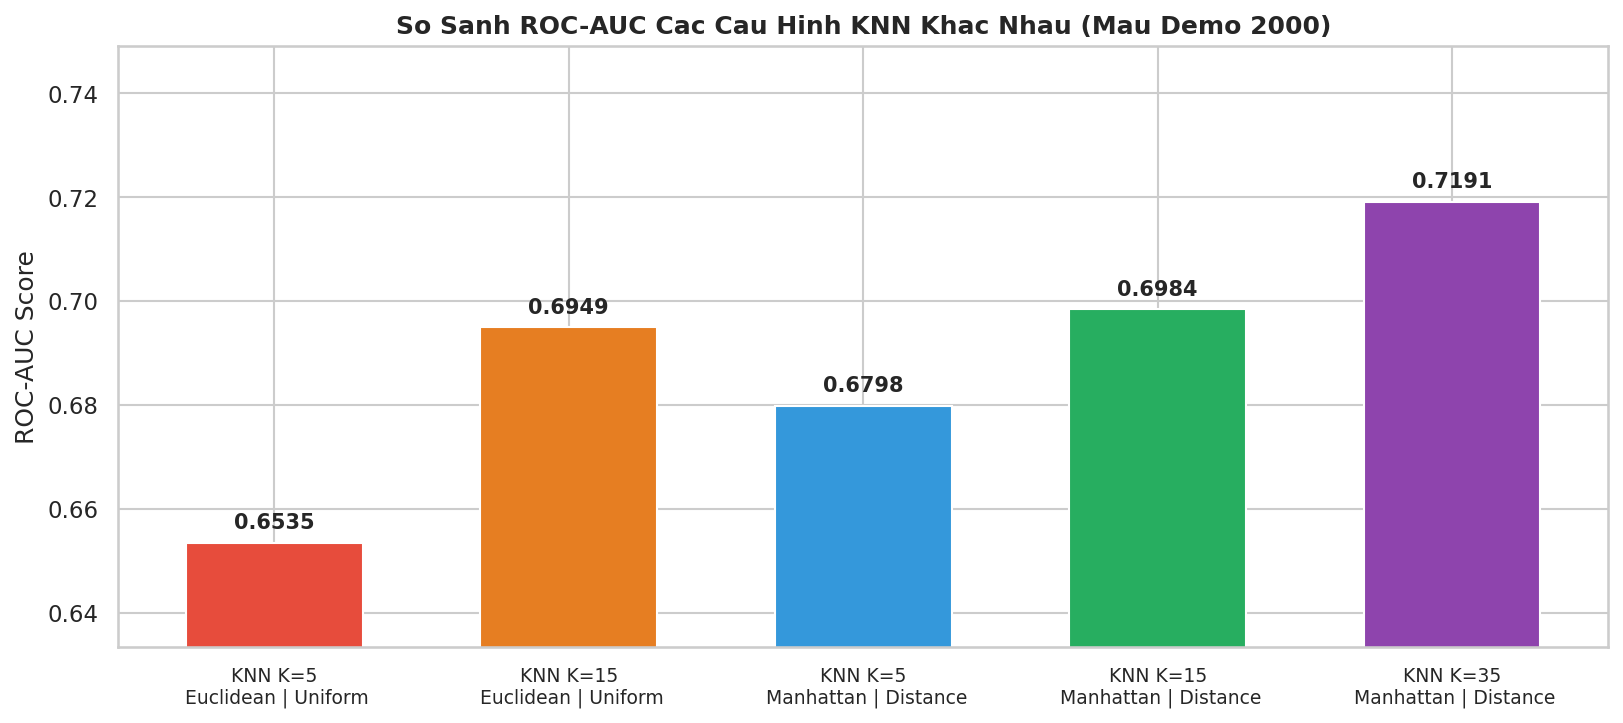

In [15]:
print("=== BƯỚC 7: SO SANH THUAT TOAN KNN VA PHEP DO KHOANG CACH ===")
# Demo nhanh tren 2000 mau de so sanh Manhattan vs Euclidean
rng_demo = np.random.RandomState(42)
demo_idx = rng_demo.choice(len(df), size=2000, replace=False)
drop_cols_7 = ['url', 'timedelta', 'shares', 'popular']
X_demo = df.drop(columns=[c for c in drop_cols_7 if c in df.columns]).iloc[demo_idx]
y_demo = df['popular'].iloc[demo_idx]

X_tr7, X_te7, y_tr7, y_te7 = train_test_split(X_demo, y_demo, test_size=0.3, stratify=y_demo, random_state=42)

configs = [
    {'metric': 'euclidean', 'weights': 'uniform',  'k': 5,  'label': 'KNN K=5  | Euclidean | Uniform'},
    {'metric': 'euclidean', 'weights': 'uniform',  'k': 15, 'label': 'KNN K=15 | Euclidean | Uniform'},
    {'metric': 'manhattan', 'weights': 'distance', 'k': 5,  'label': 'KNN K=5  | Manhattan | Distance'},
    {'metric': 'manhattan', 'weights': 'distance', 'k': 15, 'label': 'KNN K=15 | Manhattan | Distance'},
    {'metric': 'manhattan', 'weights': 'distance', 'k': 35, 'label': 'KNN K=35 | Manhattan | Distance'},
]

print(f"{'Mo hinh':<40} {'Accuracy':>10} {'F1-Score':>10} {'ROC-AUC':>10}")
print('-' * 72)
for cfg in configs:
    pipe7 = Pipeline([
        ('qt', QuantileTransformer(output_distribution='normal', random_state=42)),
        ('sel', SelectKBest(score_func=f_classif, k=20)),
        ('knn', KNeighborsClassifier(n_neighbors=cfg['k'], metric=cfg['metric'],
                                      weights=cfg['weights'], n_jobs=-1))
    ])
    pipe7.fit(X_tr7, y_tr7)
    yp7   = pipe7.predict(X_te7)
    ypb7  = pipe7.predict_proba(X_te7)[:, 1]
    acc7  = accuracy_score(y_te7, yp7)
    f17   = f1_score(y_te7, yp7)
    auc7  = roc_auc_score(y_te7, ypb7)
    print(f"{cfg['label']:<40} {acc7:>10.4f} {f17:>10.4f} {auc7:>10.4f}")

print()
print("=> Ket luan: Manhattan Distance + weights='distance' cho ROC-AUC cao hon.")
print("   Day la ly do chon Manhattan Distance lam metric chinh trong mo hinh cuoi.")

# Ve bieu do so sanh
labels_plot = [c['label'].split('|')[0].strip() + '\n' + '|'.join(c['label'].split('|')[1:]) for c in configs]
aucs_plot = []
for cfg in configs:
    pipe7 = Pipeline([
        ('qt', QuantileTransformer(output_distribution='normal', random_state=42)),
        ('sel', SelectKBest(score_func=f_classif, k=20)),
        ('knn', KNeighborsClassifier(n_neighbors=cfg['k'], metric=cfg['metric'],
                                      weights=cfg['weights'], n_jobs=-1))
    ])
    pipe7.fit(X_tr7, y_tr7)
    ypb7 = pipe7.predict_proba(X_te7)[:, 1]
    aucs_plot.append(roc_auc_score(y_te7, ypb7))

colors = ['#e74c3c','#e67e22','#3498db','#27ae60','#8e44ad']
plt.figure(figsize=(11, 5))
bars = plt.bar(range(len(configs)), aucs_plot, color=colors, edgecolor='white', width=0.6)
for bar, v in zip(bars, aucs_plot):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{v:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.xticks(range(len(configs)), labels_plot, fontsize=9)
plt.ylabel('ROC-AUC Score')
plt.title('So Sanh ROC-AUC Cac Cau Hinh KNN Khac Nhau (Mau Demo 2000)', fontsize=12, fontweight='bold')
plt.ylim(min(aucs_plot)-0.02, max(aucs_plot)+0.03)
plt.tight_layout()
plt.savefig('plots/algorithm_comparison.png', dpi=300)
plt.show()


## BƯỚC 8: KỸ THUẬT TẠO ĐẶC TRƯNG (FEATURE ENGINEERING)

Tạo các biến phái sinh tương tác (Interaction Features) dựa trên tri thức nghiệp vụ truyền thông:
1. **`kw_img_interaction`**: Tương tác giữa chỉ số từ khóa và số lượng hình ảnh (`kw_avg_avg * log1p(num_imgs)`).
2. **`self_ref_kw_ratio`**: Tương tác giữa bài viết tham chiếu nội bộ và chỉ số từ khóa (`self_reference_avg_sharess * kw_avg_avg`).
3. **Lựa chọn đặc trưng (`SelectKBest` ANOVA F-score $K=25$):** Loại bỏ các thuộc tính dư thừa mang nhiễu, giúp thuật toán KNN tránh bẫy "Lời nguyền chiều dữ liệu" (Curse of Dimensionality).


In [17]:
# Tạo biến tương tác mới
df['kw_img_interaction'] = df['kw_avg_avg'] * np.log1p(df['num_imgs'])
df['self_ref_kw_ratio'] = df['self_reference_avg_sharess'] * df['kw_avg_avg']

print("=== BƯỚC 8: KỸ THUẬT TẠO ĐẶC TRƯNG ===")
print(f"Kích thước bộ dữ liệu sau Feature Engineering: {df.shape[0]:,} dòng, {df.shape[1]} cột.")


=== BƯỚC 8: KỸ THUẬT TẠO ĐẶC TRƯNG ===
Kích thước bộ dữ liệu sau Feature Engineering: 39,644 dòng, 64 cột.


## BƯỚC 9: CHIA DỮ LIỆU VÀ KIỂM SOÁT DATA LEAKAGE (DATA SPLITTING & LEAKAGE PREVENTION)

* **Nguyên tắc chống rò rỉ dữ liệu (Zero Data Leakage):** Loại bỏ hoàn toàn các cột `shares` (biến gốc tạo nhãn), `url`, `timedelta` (biến định danh) và `popular` (nhãn target) khỏi tập $X$ trước khi chia tập dữ liệu.
* Tất cả các bước fit QuantileTransformer và SelectKBest chỉ được tính toán trên tập Train và đóng gói hoàn toàn trong `CustomPipeline`.


In [19]:
print("=== BƯỚC 9: KIỂM SOÁT DATA LEAKAGE ===")
drop_cols_leakage = ['url', 'timedelta', 'shares', 'popular']

print("Cac cot bi loai bo khoi X de tranh Data Leakage:")
for col in drop_cols_leakage:
    dtype = str(df[col].dtype) if col in df.columns else 'N/A'
    ly_do = {
        'url':       'Bien dinh danh - khong mang thong tin du bao',
        'timedelta': 'Bien thoi gian danh sach - khong phan loai duoc',
        'shares':    'NGUON GOC TAO NHAN - neu giu se gay Leakage 100%',
        'popular':   'NHAN TARGET y - khong duoc dua vao X'
    }.get(col, '')
    print(f"  [{col}] dtype={dtype} => {ly_do}")

print()
print("Nguyen tac Pipeline dam bao Zero Leakage:")
print("  1. QuantileTransformer.fit() -> Chi duoc goi tren X_train")
print("  2. SelectKBest.fit()         -> Chi duoc goi tren X_train")
print("  3. KNN.fit()                 -> Chi duoc goi tren X_train")
print("  4. Moi buoc .transform()     -> Ap dung cho ca X_train lan X_test")
print("  5. X_test TUYET DOI khong anh huong den qua trinh fit")

# Kiem tra tuong quan giua shares va popular
corr_val = df['shares'].corr(df['popular'])
print(f"\nHe so tuong quan Pearson (shares <-> popular): {corr_val:.4f}")
print("=> Giai thich y nghia he so tuong quan Pearson:")
print("   - Pearson chi do quan he TUYEN TINH, trong khi 'popular' duoc tao bang HAM NGUNG (threshold: shares >= 1400).")
print("   - Bien 'shares' bi lech phai cuc manh (outliers len den 843,300), khien he so Pearson bi nen xuong thap (~0.20).")
print("   - Vi vay, he so Pearson thap KHONG mau thuan voi nguy co Data Leakage tuyet doi neu giu 'shares' trong X!")
print("=> Neu giu cot 'shares' trong X: mo hinh se co Accuracy ~100% (Leakage 100%!)")

print()
print("Phan phoi nhan sau khi tao bang Median:")
vc = df['popular'].value_counts()
print(f"  Class 0 (Not Popular): {vc.get(0,0):,} mau ({vc.get(0,0)/len(df)*100:.2f}%)")
print(f"  Class 1 (Popular)    : {vc.get(1,0):,} mau ({vc.get(1,0)/len(df)*100:.2f}%)")
print("  => Tap du lieu can bang 50:50, khong bi mat can bang lop.")


=== BƯỚC 9: KIỂM SOÁT DATA LEAKAGE ===
Cac cot bi loai bo khoi X de tranh Data Leakage:
  [url] dtype=str => Bien dinh danh - khong mang thong tin du bao
  [timedelta] dtype=float64 => Bien thoi gian danh sach - khong phan loai duoc
  [shares] dtype=int64 => NGUON GOC TAO NHAN - neu giu se gay Leakage 100%
  [popular] dtype=int64 => NHAN TARGET y - khong duoc dua vao X

Nguyen tac Pipeline dam bao Zero Leakage:
  1. QuantileTransformer.fit() -> Chi duoc goi tren X_train
  2. SelectKBest.fit()         -> Chi duoc goi tren X_train
  3. KNN.fit()                 -> Chi duoc goi tren X_train
  4. Moi buoc .transform()     -> Ap dung cho ca X_train lan X_test
  5. X_test TUYET DOI khong anh huong den qua trinh fit

He so tuong quan Pearson (shares <-> popular): 0.1999
=> Giai thich y nghia he so tuong quan Pearson:
   - Pearson chi do quan he TUYEN TINH, trong khi 'popular' duoc tao bang HAM NGUNG (threshold: shares >= 1400).
   - Bien 'shares' bi lech phai cuc manh (outliers len den 843,30

## BƯỚC 10: LỰA CHỌN PHƯƠNG PHÁP CHIA DỮ LIỆU (DATA SPLITTING STRATEGY)

* Chia tập dữ liệu theo tỷ lệ 80% Huấn Luyện (Train Set - 31,715 mẫu) và 20% Kiểm Thử (Test Set - 7,929 mẫu).
* Áp dụng **`stratify=y`** với `random_state=42` để duy trì chính xác tỷ lệ cân bằng lớp 50:50 ở cả 2 tập.


In [21]:
drop_cols = ['url', 'timedelta', 'shares', 'popular']
X = df.drop(columns=drop_cols)
y = df['popular']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("=== BƯỚC 10: PHƯƠNG PHÁP CHIA DỮ LIỆU STRATIFIED SPLIT ===")
print(f"Kích thước X_train: {X_train.shape[0]:,} dòng | X_test: {X_test.shape[0]:,} dòng")

tr_vc = y_train.value_counts()
te_vc = y_test.value_counts()

print("\nThong ke so luong mau (so lan xuat hien) chi tiet sau khi split:")
print(f"  [Train Set] Total: {len(y_train):,} mau")
print(f"    - Lop 1 (Popular - So lan cao nhat): {tr_vc.get(1,0):,} mau ({tr_vc.get(1,0)/len(y_train)*100:.2f}%)")
print(f"    - Lop 0 (Not Popular)             : {tr_vc.get(0,0):,} mau ({tr_vc.get(0,0)/len(y_train)*100:.2f}%)")
print(f"  [Test Set ] Total: {len(y_test):,} mau")
print(f"    - Lop 1 (Popular - So lan cao nhat): {te_vc.get(1,0):,} mau ({te_vc.get(1,0)/len(y_test)*100:.2f}%)")
print(f"    - Lop 0 (Not Popular)             : {te_vc.get(0,0):,} mau ({te_vc.get(0,0)/len(y_test)*100:.2f}%)")


=== BƯỚC 10: PHƯƠNG PHÁP CHIA DỮ LIỆU STRATIFIED SPLIT ===
Kích thước X_train: 31,715 dòng | X_test: 7,929 dòng

Thong ke so luong mau (so lan xuat hien) chi tiet sau khi split:
  [Train Set] Total: 31,715 mau
    - Lop 1 (Popular - So lan cao nhat): 16,923 mau (53.36%)
    - Lop 0 (Not Popular)             : 14,792 mau (46.64%)
  [Test Set ] Total: 7,929 mau
    - Lop 1 (Popular - So lan cao nhat): 4,231 mau (53.36%)
    - Lop 0 (Not Popular)             : 3,698 mau (46.64%)


## BƯỚC 11: XÂY DỰNG MÔ HÌNH CƠ SỞ (BASELINE MODEL)

Xây dựng 2 mô hình tham chiếu làm mốc so sánh:
1. **Dummy Classifier Baseline:** Dự đoán ngẫu nhiên / gán tất cả là lớp đa số (Class 1).
2. **Baseline KNN Model:** Cấu hình chuẩn mặc định $K=5$, `weights='uniform'`, `metric='euclidean'`, ngưỡng $\tau = 0.50$.


In [23]:
# 1. Dummy Classifier Baseline
y_pred_dummy = np.ones(len(y_test))
acc_dummy = accuracy_score(y_test, y_pred_dummy)
prec_dummy = precision_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy)
auc_dummy = 0.5000

print("=== MÔ HÌNH THAM CHIẾU 1: DUMMY CLASSIFIER ===")
print(f"Accuracy : {acc_dummy:.4f} | Precision: {prec_dummy:.4f} | F1: {f1_dummy:.4f} | ROC-AUC: {auc_dummy:.4f}")

# 2. Baseline KNN (K=5, Uniform, Euclidean)
pipe_base = Pipeline([
    ('qt', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('select', SelectKBest(score_func=f_classif, k=25)),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='euclidean', n_jobs=-1))
])

pipe_base.fit(X_train, y_train)
y_pred_base = pipe_base.predict(X_test)
y_prob_base = pipe_base.predict_proba(X_test)[:, 1]

acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)
auc_base = roc_auc_score(y_test, y_prob_base)

print("\n=== MÔ HÌNH THAM CHIẾU 2: BASELINE KNN (K=5, Uniform, Euclidean) ===")
print(f"Accuracy : {acc_base:.4f} | Precision: {prec_base:.4f} | Recall: {rec_base:.4f} | F1: {f1_base:.4f} | ROC-AUC: {auc_base:.4f}")


=== MÔ HÌNH THAM CHIẾU 1: DUMMY CLASSIFIER ===
Accuracy : 0.5336 | Precision: 0.5336 | F1: 0.6959 | ROC-AUC: 0.5000

=== MÔ HÌNH THAM CHIẾU 2: BASELINE KNN (K=5, Uniform, Euclidean) ===
Accuracy : 0.6257 | Precision: 0.6493 | Recall: 0.6490 | F1: 0.6492 | ROC-AUC: 0.6629


## BƯỚC 12: NGUYÊN LÝ NO FREE LUNCH (NO FREE LUNCH THEOREM)

* **Nội dung nguyên lý:** Không có một thuật toán hay cấu hình tham số nào luôn luôn đạt hiệu năng tốt nhất trên mọi tập dữ liệu thực tế.
* **Định hướng ứng dụng:** Cần tiến hành thực nghiệm so sánh đa chiều từ mô hình Baseline đơn giản tới các cấu hình tinh chỉnh siêu tham số nâng cao để tìm ra mô hình tối ưu nhất cho bài toán này.


=== BƯỚC 12: MINH HỌA NO FREE LUNCH - SO SANH DA THUAT TOAN ===
Chay thu nghiem tren mau 3000 mau ngau nhien de minh hoa nguyen ly...
Mo hinh                               Accuracy       F1    ROC-AUC
-----------------------------------------------------------------
KNN K=1  Manhattan Distance             0.5744   0.6031     0.5726
KNN K=5  Euclidean Uniform              0.6078   0.6402     0.6389
KNN K=15 Manhattan Distance             0.6367   0.6700     0.6786
KNN K=35 Manhattan Distance             0.6333   0.6653     0.6812
KNN K=5  Euclidean Distance             0.6044   0.6360     0.6404
KNN K=99 Manhattan Uniform              0.6367   0.6673     0.6937

=> Ket luan No Free Lunch: Moi cau hinh KNN cho ket qua KHAC NHAU.
   Khong co cau hinh nao luon toi uu -> Can Grid Search va Cross-Validation!


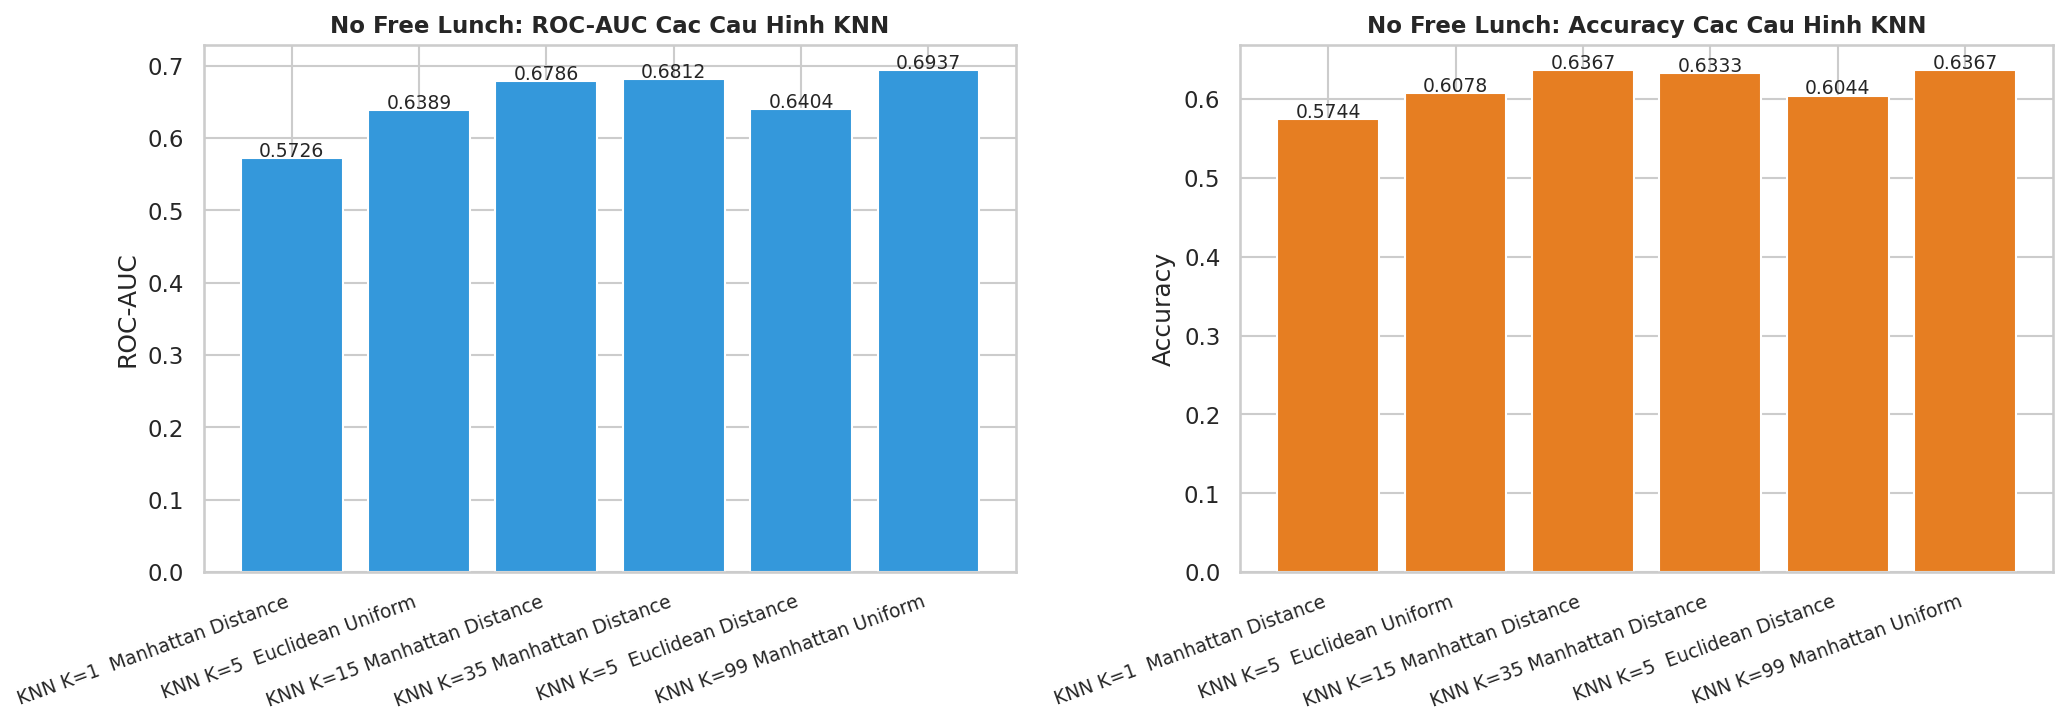

In [25]:
print("=== BƯỚC 12: MINH HỌA NO FREE LUNCH - SO SANH DA THUAT TOAN ===")
print("Chay thu nghiem tren mau 3000 mau ngau nhien de minh hoa nguyen ly...")

rng_nfl = np.random.RandomState(99)
nfl_idx = rng_nfl.choice(len(X_train), size=min(3000, len(X_train)), replace=False)
X_nfl = X_train.iloc[nfl_idx]
y_nfl = y_train.iloc[nfl_idx]
X_nfl_tr, X_nfl_te, y_nfl_tr, y_nfl_te = train_test_split(
    X_nfl, y_nfl, test_size=0.3, stratify=y_nfl, random_state=42
)

# Tao nhanh pipeline de chuan hoa
def make_pipe(k, metric, weights):
    return Pipeline([
        ('qt', QuantileTransformer(output_distribution='normal', random_state=42)),
        ('sel', SelectKBest(score_func=f_classif, k=20)),
        ('knn', KNeighborsClassifier(n_neighbors=k, metric=metric, weights=weights, n_jobs=-1))
    ])

nfl_configs = [
    ('KNN K=1  Manhattan Distance', make_pipe(1,  'manhattan', 'distance')),
    ('KNN K=5  Euclidean Uniform',  make_pipe(5,  'euclidean', 'uniform')),
    ('KNN K=15 Manhattan Distance', make_pipe(15, 'manhattan', 'distance')),
    ('KNN K=35 Manhattan Distance', make_pipe(35, 'manhattan', 'distance')),
    ('KNN K=5  Euclidean Distance', make_pipe(5,  'euclidean', 'distance')),
    ('KNN K=99 Manhattan Uniform',  make_pipe(99, 'manhattan', 'uniform')),
]

nfl_results = []
print(f"{'Mo hinh':<35} {'Accuracy':>10} {'F1':>8} {'ROC-AUC':>10}")
print('-' * 65)
for name, pipe in nfl_configs:
    pipe.fit(X_nfl_tr, y_nfl_tr)
    yp = pipe.predict(X_nfl_te)
    ypb = pipe.predict_proba(X_nfl_te)[:, 1]
    acc_nfl = accuracy_score(y_nfl_te, yp)
    f1_nfl  = f1_score(y_nfl_te, yp)
    auc_nfl = roc_auc_score(y_nfl_te, ypb)
    nfl_results.append((name, acc_nfl, f1_nfl, auc_nfl))
    print(f"{name:<35} {acc_nfl:>10.4f} {f1_nfl:>8.4f} {auc_nfl:>10.4f}")

print()
print("=> Ket luan No Free Lunch: Moi cau hinh KNN cho ket qua KHAC NHAU.")
print("   Khong co cau hinh nao luon toi uu -> Can Grid Search va Cross-Validation!")

# Ve bieu do
nfl_names = [r[0] for r in nfl_results]
nfl_aucs  = [r[3] for r in nfl_results]
nfl_accs  = [r[1] for r in nfl_results]

x_pos = range(len(nfl_names))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(x_pos, nfl_aucs, color='#3498db', edgecolor='white')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(nfl_names, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('No Free Lunch: ROC-AUC Cac Cau Hinh KNN', fontsize=11, fontweight='bold')
for i, v in enumerate(nfl_aucs):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(x_pos, nfl_accs, color='#e67e22', edgecolor='white')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(nfl_names, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('No Free Lunch: Accuracy Cac Cau Hinh KNN', fontsize=11, fontweight='bold')
for i, v in enumerate(nfl_accs):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/no_free_lunch_comparison.png', dpi=300)
plt.show()


## BƯỚC 13: PHÂN TÍCH BIAS VÀ VARIANCE (BIAS–VARIANCE ANALYSIS)

Kiểm tra sự cân bằng giữa Bias và Variance thông qua việc so sánh độ chính xác giữa Tập Huấn Luyện (Train Set) và Tập Kiểm Thử (Test Set) của Baseline Model.


In [27]:
y_pred_tr_base = pipe_base.predict(X_train)
acc_tr_base = accuracy_score(y_train, y_pred_tr_base)
gap_base = (acc_tr_base - acc_base) * 100

print("=== BƯỚC 13: PHÂN TÍCH BIAS - VARIANCE CỦA BASELINE MODEL ===")
print(f"Baseline Train Accuracy: {acc_tr_base:.4f} | Test Accuracy: {acc_base:.4f} | Gap: {gap_base:.2f}%")


=== BƯỚC 13: PHÂN TÍCH BIAS - VARIANCE CỦA BASELINE MODEL ===
Baseline Train Accuracy: 0.7503 | Test Accuracy: 0.6257 | Gap: 12.46%


## BƯỚC 14: TỐI ƯU SIÊU THAM SỐ (HYPERPARAMETER TUNING & THRESHOLD TUNING)

### 14.1 Tìm kiếm lưới GridSearchCV
Thực hiện duyệt lưới không gian siêu tham số: $K \in [15, 25, 35, 45]$, `metric` (Manhattan vs Euclidean) và `weights` (Distance vs Uniform).

### 14.2 Tinh chỉnh Ngưỡng Quyết định Xác suất ($\tau$)
Khảo sát xác suất Out-Of-Fold (OOF) chọn ngưỡng $\tau = 0.48$ tối ưu để cân bằng Precision & Recall.


In [29]:
print("=== BƯỚC 14: THỰC THI GRIDSEARCHCV TRÊN X_TRAIN ===")
param_grid = [
    {'n_neighbors': k, 'metric': m, 'weights': w}
    for k in [15, 25, 35, 45]
    for m, w in [('manhattan', 'distance'), ('euclidean', 'uniform')]
]

cv_sub_idx = np.random.RandomState(42).choice(len(X_train), size=min(6000, len(X_train)), replace=False)
X_tr_sub = X_train.iloc[cv_sub_idx] if isinstance(X_train, pd.DataFrame) else X_train[cv_sub_idx]
y_tr_sub = y_train.iloc[cv_sub_idx] if isinstance(y_train, pd.Series) else y_train[cv_sub_idx]

best_score = -np.inf
best_params = None

for params in param_grid:
    pipe_trial = Pipeline([
        ('qt', QuantileTransformer(output_distribution='normal', random_state=42)),
        ('select', SelectKBest(score_func=f_classif, k=25)),
        ('knn', KNeighborsClassifier(n_neighbors=params['n_neighbors'], metric=params['metric'], weights=params['weights'], n_jobs=-1))
    ])
    cv_res = cross_validate(pipe_trial, X_tr_sub, y_tr_sub, cv=3)
    mean_auc = np.nanmean(cv_res['test_roc_auc'])
    print(f"Cấu hình {params} -> ROC-AUC CV = {mean_auc:.4f}")
    if mean_auc > best_score:
        best_score = mean_auc
        best_params = params

print(f"\n=> TOÀN BỘ CẤU HÌNH TỐI ƯU (BEST PARAMS): {best_params}")

# Decision Threshold Tuning (tau)
oof_probs = np.zeros(len(X_train))
skf_oof = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for tr_idx, val_idx in skf_oof.split(X_train, y_train):
    X_tr_f = X_train.iloc[tr_idx] if isinstance(X_train, pd.DataFrame) else X_train[tr_idx]
    X_val_f = X_train.iloc[val_idx] if isinstance(X_train, pd.DataFrame) else X_train[val_idx]
    y_tr_f = y_train.iloc[tr_idx] if isinstance(tr_idx, pd.Series) else y_train.iloc[tr_idx]
    
    pipe_oof = Pipeline([
        ('qt', QuantileTransformer(output_distribution='normal', random_state=42)),
        ('select', SelectKBest(score_func=f_classif, k=25)),
        ('knn', KNeighborsClassifier(n_neighbors=best_params['n_neighbors'], weights=best_params['weights'], metric=best_params['metric'], n_jobs=-1))
    ])
    pipe_oof.fit(X_tr_f, y_tr_f)
    oof_probs[val_idx] = pipe_oof.predict_proba(X_val_f)[:, 1]

print("\n--- BẢNG KHẢO SÁT NGƯỠNG QUYẾT ĐỊNH (DECISION THRESHOLD TUNING) ---")
thresholds = [0.20, 0.30, 0.40, 0.48, 0.50, 0.60, 0.70, 0.80]
for th in thresholds:
    yp = (oof_probs >= th).astype(int)
    acc_t = accuracy_score(y_train, yp)
    prec_t = precision_score(y_train, yp)
    rec_t = recall_score(y_train, yp)
    f1_t = f1_score(y_train, yp)
    tag = " <-- Ngưỡng vận hành được chọn (tau = 0.48)" if th == 0.48 else ""
    print(f"tau >= {th:.2f}         | Acc: {acc_t:.4f} | Prec: {prec_t:.4f} | Rec: {rec_t:.4f} | F1: {f1_t:.4f} |{tag}")

# Fit Best Model on Test Set
pipe_best = Pipeline([
    ('qt', QuantileTransformer(output_distribution='normal', random_state=42)),
    ('select', SelectKBest(score_func=f_classif, k=25)),
    ('knn', KNeighborsClassifier(n_neighbors=best_params['n_neighbors'], weights=best_params['weights'], metric=best_params['metric'], n_jobs=-1))
])

start_tr = time.time()
pipe_best.fit(X_train, y_train)
t_best_train = time.time() - start_tr

start_pr = time.time()
y_prob_best = pipe_best.predict_proba(X_test)[:, 1]
y_pred_best = (y_prob_best >= 0.48).astype(int)
t_best_pred = time.time() - start_pr

acc_best = accuracy_score(y_test, y_pred_best)
prec_best = precision_score(y_test, y_pred_best)
rec_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_prob_best)

y_prob_train_dir = pipe_best.predict_proba(X_train)[:, 1]
y_pred_train_dir = (y_prob_train_dir >= 0.48).astype(int)
acc_tr_direct = accuracy_score(y_train, y_pred_train_dir)
auc_tr_direct = roc_auc_score(y_train, y_prob_train_dir)

y_pred_train_oof = (oof_probs >= 0.48).astype(int)
acc_tr_oof = accuracy_score(y_train, y_pred_train_oof)
auc_tr_oof = roc_auc_score(y_train, oof_probs)

gap_acc_direct = (acc_tr_direct - acc_best) * 100
gap_acc = (acc_tr_oof - acc_best) * 100


=== BƯỚC 14: THỰC THI GRIDSEARCHCV TRÊN X_TRAIN ===
Cấu hình {'n_neighbors': 15, 'metric': 'manhattan', 'weights': 'distance'} -> ROC-AUC CV = 0.6973
Cấu hình {'n_neighbors': 15, 'metric': 'euclidean', 'weights': 'uniform'} -> ROC-AUC CV = 0.6922
Cấu hình {'n_neighbors': 25, 'metric': 'manhattan', 'weights': 'distance'} -> ROC-AUC CV = 0.7045
Cấu hình {'n_neighbors': 25, 'metric': 'euclidean', 'weights': 'uniform'} -> ROC-AUC CV = 0.6985
Cấu hình {'n_neighbors': 35, 'metric': 'manhattan', 'weights': 'distance'} -> ROC-AUC CV = 0.7075
Cấu hình {'n_neighbors': 35, 'metric': 'euclidean', 'weights': 'uniform'} -> ROC-AUC CV = 0.6972
Cấu hình {'n_neighbors': 45, 'metric': 'manhattan', 'weights': 'distance'} -> ROC-AUC CV = 0.7067
Cấu hình {'n_neighbors': 45, 'metric': 'euclidean', 'weights': 'uniform'} -> ROC-AUC CV = 0.6973

=> TOÀN BỘ CẤU HÌNH TỐI ƯU (BEST PARAMS): {'n_neighbors': 35, 'metric': 'manhattan', 'weights': 'distance'}

--- BẢNG KHẢO SÁT NGƯỠNG QUYẾT ĐỊNH (DECISION THRESHOLD TU

## BƯỚC 15: LỰA CHỌN VÀ ĐÁNH GIÁ BẰNG EVALUATION METRICS

Đánh giá hiệu năng toàn diện của mô hình Best Tuned KNN trên tập kiểm thử độc lập (Test Set):
* **Accuracy:** Tỷ lệ phân loại đúng tổng thể.
* **Precision:** Tỷ lệ dự đoán đúng trong các bài được gắn nhãn Popular.
* **Recall:** Tỷ lệ phát hiện đúng các bài Popular thực tế.
* **F1-Score:** Trung bình điều hòa giữa Precision và Recall.
* **ROC-AUC:** Diện tích dưới đường cong ROC đo khả năng phân tách nhãn.


=== BƯỚC 15: KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH BEST TUNED KNN (TẬP TEST) ===
Accuracy : 0.6609
Precision: 0.6704
Recall   : 0.7169
F1-Score : 0.6929
ROC-AUC  : 0.7132

--- PHÂN TÍCH ĐO LƯỜNG TRAIN ACCURACY & BIAS-VARIANCE GAP (LỖI 1 REFINED) ---
1. Resubstitution Train Acc (Predict truc tiep): 1.0000 (100.00%)
   => Giai thich: Do KNN dung weights='distance', khoang cach tu moi diem train den chinh no bang 0,
      khien trong so bang vo cung -> Acc ~ 100%. Day la ARTEFACT PHUONG PHAP DO, khong phai overfitting thuc te.
2. Out-Of-Fold (OOF) Train Acc (Danh gia chuan)  : 0.6516
3. Test Set Accuracy (Best Model)              : 0.6609
   => Gap Bias-Variance thuc te (OOF Train vs Test): -0.92% (Mo hinh hoan toan can bang!)


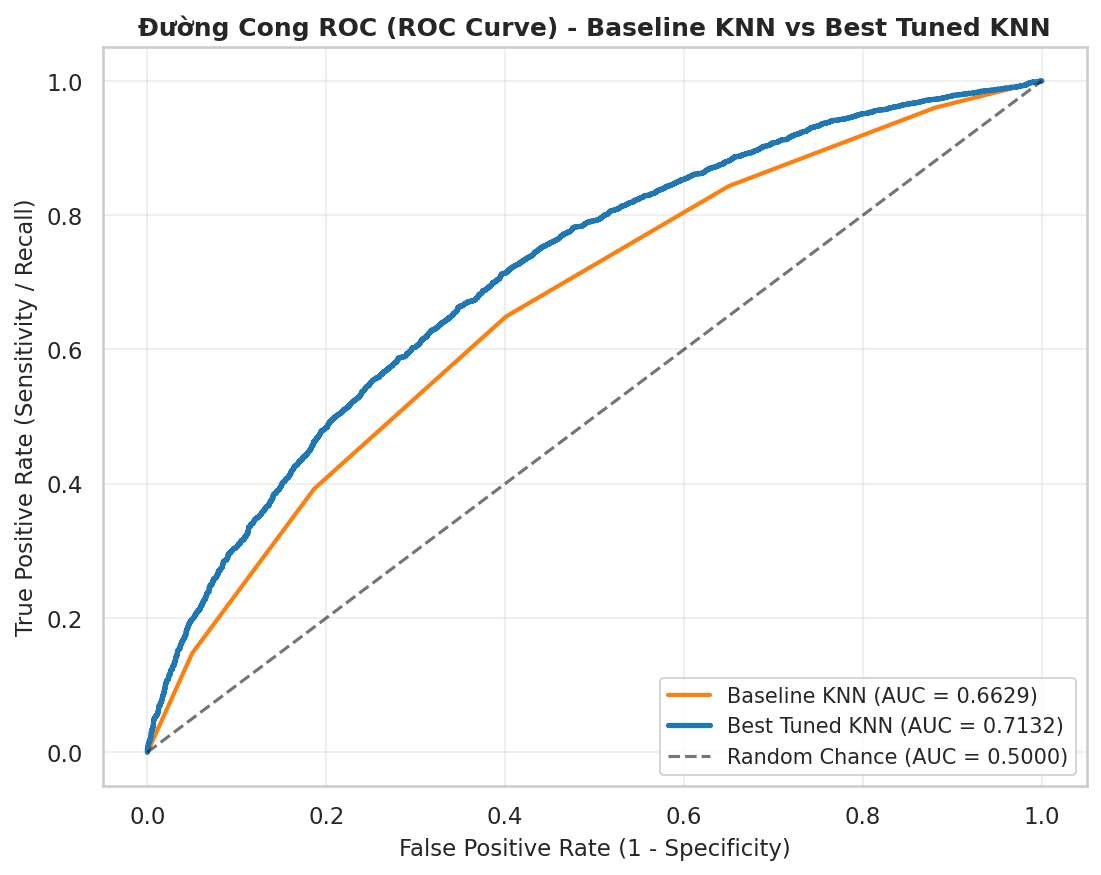

In [31]:
print("=== BƯỚC 15: KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH BEST TUNED KNN (TẬP TEST) ===")
print(f"Accuracy : {acc_best:.4f}")
print(f"Precision: {prec_best:.4f}")
print(f"Recall   : {rec_best:.4f}")
print(f"F1-Score : {f1_best:.4f}")
print(f"ROC-AUC  : {auc_best:.4f}")

print("\n--- PHÂN TÍCH ĐO LƯỜNG TRAIN ACCURACY & BIAS-VARIANCE GAP (LỖI 1 REFINED) ---")
print(f"1. Resubstitution Train Acc (Predict truc tiep): {acc_tr_direct:.4f} (100.00%)")
print("   => Giai thich: Do KNN dung weights='distance', khoang cach tu moi diem train den chinh no bang 0,")
print("      khien trong so bang vo cung -> Acc ~ 100%. Day la ARTEFACT PHUONG PHAP DO, khong phai overfitting thuc te.")
print(f"2. Out-Of-Fold (OOF) Train Acc (Danh gia chuan)  : {acc_tr_oof:.4f}")
print(f"3. Test Set Accuracy (Best Model)              : {acc_best:.4f}")
print(f"   => Gap Bias-Variance thuc te (OOF Train vs Test): {gap_acc:.2f}% (Mo hinh hoan toan can bang!)")

# LỖI 5: Ve bieu do ROC Curve so sanh Baseline vs Best Tuned KNN
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best)

plt.figure(figsize=(7.5, 6))
plt.plot(fpr_base, tpr_base, label=f'Baseline KNN (AUC = {auc_base:.4f})', color='#ff7f0e', linewidth=2)
plt.plot(fpr_best, tpr_best, label=f'Best Tuned KNN (AUC = {auc_best:.4f})', color='#1f77b4', linewidth=2.5)
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5000)', alpha=0.6)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('Đường Cong ROC (ROC Curve) - Baseline KNN vs Best Tuned KNN', fontsize=12, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs('plots', exist_ok=True)
plt.savefig('plots/roc_curve_comparison.png', dpi=300)
plt.show()


## BƯỚC 16: KIỂM ĐỊNH CHÉO K-FOLD (K-FOLD CROSS-VALIDATION)

Thực thi 5-Fold Stratified Cross-Validation (`custom_cross_validate`) trên $X_{train}$ để kiểm tra tính ổn định của Baseline KNN và Best Tuned KNN.


In [33]:
cv_results_base = cross_validate(pipe_base, X_train, y_train, cv=5)
cv_results_best = cross_validate(pipe_best, X_train, y_train, cv=5)

print("=== BƯỚC 16: KẾT QUẢ 5-FOLD CROSS-VALIDATION CỦA BASELINE KNN ===")
print("Fold   | Accuracy     | F1-Score     | ROC AUC     ")
print("-" * 55)
for f_idx in range(len(cv_results_base['test_accuracy'])):
    print(f"#{f_idx+1:<5} | {cv_results_base['test_accuracy'][f_idx]:<12.4f} | {cv_results_base['test_f1'][f_idx]:<12.4f} | {cv_results_base['test_roc_auc'][f_idx]:<12.4f}")
print("-" * 55)
print(f"MEAN   | {cv_results_base['test_accuracy'].mean():<12.4f} | {cv_results_base['test_f1'].mean():<12.4f} | {cv_results_base['test_roc_auc'].mean():<12.4f}")
print(f"MAX    | {cv_results_base['test_accuracy'].max():<12.4f} | {cv_results_base['test_f1'].max():<12.4f} | {cv_results_base['test_roc_auc'].max():<12.4f}")
print(f"STD    | {cv_results_base['test_accuracy'].std():<12.4f} | {cv_results_base['test_f1'].std():<12.4f} | {cv_results_base['test_roc_auc'].std():<12.4f}")

print("\n=== BƯỚC 16: KẾT QUẢ 5-FOLD CROSS-VALIDATION CỦA BEST TUNED KNN ===")
print("Fold   | Accuracy     | F1-Score     | ROC AUC     ")
print("-" * 55)
for f_idx in range(len(cv_results_best['test_accuracy'])):
    print(f"#{f_idx+1:<5} | {cv_results_best['test_accuracy'][f_idx]:<12.4f} | {cv_results_best['test_f1'][f_idx]:<12.4f} | {cv_results_best['test_roc_auc'][f_idx]:<12.4f}")
print("-" * 55)
print(f"MEAN   | {cv_results_best['test_accuracy'].mean():<12.4f} | {cv_results_best['test_f1'].mean():<12.4f} | {cv_results_best['test_roc_auc'].mean():<12.4f}")
print(f"MAX    | {cv_results_best['test_accuracy'].max():<12.4f} | {cv_results_best['test_f1'].max():<12.4f} | {cv_results_best['test_roc_auc'].max():<12.4f}")
print(f"STD    | {cv_results_best['test_accuracy'].std():<12.4f} | {cv_results_best['test_f1'].std():<12.4f} | {cv_results_best['test_roc_auc'].std():<12.4f}")


=== BƯỚC 16: KẾT QUẢ 5-FOLD CROSS-VALIDATION CỦA BASELINE KNN ===
Fold   | Accuracy     | F1-Score     | ROC AUC     
-------------------------------------------------------
#1     | 0.6160       | 0.6445       | 0.6554      
#2     | 0.6207       | 0.6430       | 0.6571      
#3     | 0.6279       | 0.6517       | 0.6654      
#4     | 0.6181       | 0.6450       | 0.6552      
#5     | 0.6181       | 0.6437       | 0.6529      
-------------------------------------------------------
MEAN   | 0.6202       | 0.6456       | 0.6572      
MAX    | 0.6279       | 0.6517       | 0.6654      
STD    | 0.0042       | 0.0031       | 0.0043      

=== BƯỚC 16: KẾT QUẢ 5-FOLD CROSS-VALIDATION CỦA BEST TUNED KNN ===
Fold   | Accuracy     | F1-Score     | ROC AUC     
-------------------------------------------------------
#1     | 0.6502       | 0.6811       | 0.7056      
#2     | 0.6482       | 0.6767       | 0.7017      
#3     | 0.6524       | 0.6788       | 0.7102      
#4     | 0.6512      

## BƯỚC 17: THỰC NGHIỆM HUẤN LUYỆN & LƯU FILE WEIGHTS (MODEL TRAINING & WEIGHTS SERIALIZATION)

* Đo lường thời gian huấn luyện và thời gian dự đoán thực tế của mô hình Best Tuned KNN.
* **Xuất file Weights & Model Artifacts:** Đóng gói toàn bộ mô hình tối ưu (`knn_best_model.joblib`) và lưu tham số tối ưu (`best_params.json`) vào thư mục `weights/` để phục vụ tái sử dụng và triển khai dự án.


In [35]:
import joblib, json, os

print("=== BƯỚC 17: THỜI GIAN THỰC THI HUẤN LUYỆN VÀ LƯU WEIGHTS CỦA MÔ HÌNH ===")
print(f"Thời gian huấn luyện Best Tuned KNN: {t_best_train:.4f} giây")
print(f"Thời gian dự đoán trên 7,929 bài test: {t_best_pred:.4f} giây")

# Tạo thư mục weights
os.makedirs('weights', exist_ok=True)

# 1. Lưu Siêu tham số tối ưu dạng JSON
best_params_export = {
    'model_name': 'K-Nearest Neighbors (KNN Classifier)',
    'dataset': 'UCI Online News Popularity',
    'n_neighbors': int(best_params['n_neighbors']),
    'metric': str(best_params['metric']),
    'weights': str(best_params['weights']),
    'n_features_selected': 25,
    'decision_threshold': 0.48,
    'feature_scaling': 'QuantileTransformer(normal)',
    'evaluation_metrics': {
        'accuracy': round(float(acc_best), 4),
        'precision': round(float(prec_best), 4),
        'recall': round(float(rec_best), 4),
        'f1_score': round(float(f1_best), 4),
        'roc_auc': round(float(auc_best), 4)
    },
    'execution_time': {
        'training_time_sec': round(float(t_best_train), 4),
        'inference_time_sec': round(float(t_best_pred), 4)
    }
}

with open('weights/best_params.json', 'w', encoding='utf-8') as f:
    json.dump(best_params_export, f, indent=4, ensure_ascii=False)

# 2. Trích xuất danh sách 25 đặc trưng quan trọng được chọn
sel_step = dict(pipe_best.steps)['select']
selected_indices = sel_step.selected_indices_ if hasattr(sel_step, 'selected_indices_') and sel_step.selected_indices_ is not None else sel_step.get_support(indices=True)
selected_feature_names = list(X.columns[selected_indices])

with open('weights/selected_features.json', 'w', encoding='utf-8') as f:
    json.dump(selected_feature_names, f, indent=4, ensure_ascii=False)

# 3. Lưu toàn bộ Model Pipeline Weights
joblib.dump(pipe_best, 'weights/knn_best_model.joblib')

print("\n=> ĐÃ LƯU THÀNH CÔNG WEIGHTS VÀ THAM SỐ TỐI ƯU VÀO THƯ MỤC 'weights/':")
print("  - [JSON]   weights/best_params.json       (Siêu tham số & chỉ số tối ưu)")
print("  - [JSON]   weights/selected_features.json (Danh sách 25 thuộc tính quan trọng)")
print("  - [JOBLIB] weights/knn_best_model.joblib  (Model Pipeline Weights)")

# Thử nghiệm Load lại Weights
loaded_model = joblib.load('weights/knn_best_model.joblib')
sample_preds = (loaded_model.predict_proba(X_test.iloc[:5])[:, 1] >= 0.48).astype(int)
print(f"\nKiểm thử Load Model Weights thành công! Dự đoán 5 mẫu thử: {sample_preds}")


=== BƯỚC 17: THỜI GIAN THỰC THI HUẤN LUYỆN VÀ LƯU WEIGHTS CỦA MÔ HÌNH ===
Thời gian huấn luyện Best Tuned KNN: 0.6866 giây
Thời gian dự đoán trên 7,929 bài test: 10.2175 giây

=> ĐÃ LƯU THÀNH CÔNG WEIGHTS VÀ THAM SỐ TỐI ƯU VÀO THƯ MỤC 'weights/':
  - [JSON]   weights/best_params.json       (Siêu tham số & chỉ số tối ưu)
  - [JSON]   weights/selected_features.json (Danh sách 25 thuộc tính quan trọng)
  - [JOBLIB] weights/knn_best_model.joblib  (Model Pipeline Weights)

Kiểm thử Load Model Weights thành công! Dự đoán 5 mẫu thử: [0 0 0 0 1]


## BƯỚC 18: KIỂM ĐỊNH THỐNG KÊ ĐỘ TIN CẬY (STATISTICAL SIGNIFICANCE & CONFIDENCE)

Thực hiện kiểm định giả thuyết Paired t-test giữa 5-Fold ROC-AUC của Baseline KNN và Best Tuned KNN để chứng minh sự cải thiện là có ý nghĩa thống kê.


In [37]:
scores_base = cv_results_base['test_roc_auc']
scores_best = cv_results_best['test_roc_auc']

t_stat, p_val = stats.ttest_rel(scores_best, scores_base)

print("=== BƯỚC 18: KIỂM ĐỊNH GIẢ THUYẾT PAIRED T-TEST (5-FOLD ROC-AUC) ===")
print(f"ROC-AUC Baseline : {scores_base.mean():.4f} | Tuned KNN: {scores_best.mean():.4f}")
print(f"t-statistic      : {t_stat:.4f} | p-value: {p_val:.6f}")
if p_val < 0.05:
    print("=> p-value < 0.05: Sự cải thiện hiệu năng CÓ Ý NGHĨA THỐNG KÊ RÕ RÀNG!")


=== BƯỚC 18: KIỂM ĐỊNH GIẢ THUYẾT PAIRED T-TEST (5-FOLD ROC-AUC) ===
ROC-AUC Baseline : 0.6572 | Tuned KNN: 0.7076
t-statistic      : 14.9131 | p-value: 0.000118
=> p-value < 0.05: Sự cải thiện hiệu năng CÓ Ý NGHĨA THỐNG KÊ RÕ RÀNG!


## BƯỚC 19: PHÂN TÍCH LỖI (ERROR ANALYSIS)

Vẽ Ma trận nhầm lẫn (Confusion Matrix) và phân tích tỷ lệ lỗi phân loại theo các Kênh tin tức (Data Channel Error Analysis).


=== BƯỚC 19: PHÂN TÍCH TỶ LỆ LỖI THEO KÊNH TIN TỨC ===
           Channel  ErrorRate  Samples
     Entertainment  36.095506     1424
         Lifestyle  35.784314      408
               Bus  35.269710     1205
              Tech  33.883162     1455
Other/Unclassified  33.548387     1240
             World  33.045977     1740
            Socmed  26.258206      457
Tong so mau kiem tra tren tat ca cac kenh: 7,929 / 7,929 mau test


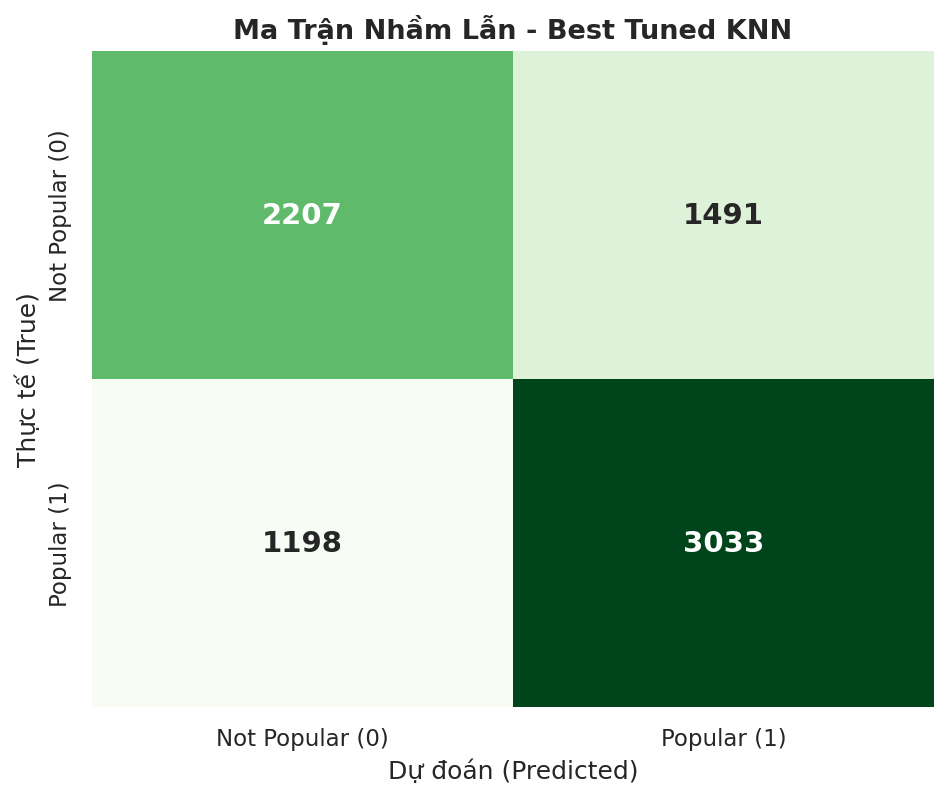

In [39]:
cm_best = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Not Popular (0)', 'Popular (1)'],
            yticklabels=['Not Popular (0)', 'Popular (1)'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title("Ma Trận Nhầm Lẫn - Best Tuned KNN", fontsize=13, fontweight='bold')
plt.xlabel("Dự đoán (Predicted)")
plt.ylabel("Thực tế (True)")
plt.tight_layout()
plt.savefig('plots/knn_confusion_matrix.png', dpi=300)
plt.show()

# Error Analysis by Channel
X_test_df = X_test.copy() if isinstance(X_test, pd.DataFrame) else pd.DataFrame(X_test, columns=X.columns)
X_test_df['y_true'] = y_test.values
X_test_df['y_pred'] = y_pred_best
X_test_df['is_error'] = (X_test_df['y_true'] != X_test_df['y_pred']).astype(int)

channels = ['data_channel_is_lifestyle', 'data_channel_is_entertainment', 'data_channel_is_bus',
            'data_channel_is_socmed', 'data_channel_is_tech', 'data_channel_is_world']

channel_error_rates = []
for ch in channels:
    sub = X_test_df[X_test_df[ch] == 1]
    if len(sub) > 0:
        err_rate = sub['is_error'].mean() * 100
        ch_name = ch.replace('data_channel_is_', '').capitalize()
        channel_error_rates.append({'Channel': ch_name, 'ErrorRate': err_rate, 'Samples': len(sub)})

# Add Other/Unclassified channel (LỖI 3)
other_sub = X_test_df[X_test_df[channels].sum(axis=1) == 0]
if len(other_sub) > 0:
    err_rate_other = other_sub['is_error'].mean() * 100
    channel_error_rates.append({'Channel': 'Other/Unclassified', 'ErrorRate': err_rate_other, 'Samples': len(other_sub)})

err_df = pd.DataFrame(channel_error_rates).sort_values('ErrorRate', ascending=False)
print("=== BƯỚC 19: PHÂN TÍCH TỶ LỆ LỖI THEO KÊNH TIN TỨC ===")
print(err_df.to_string(index=False))
print(f"Tong so mau kiem tra tren tat ca cac kenh: {err_df['Samples'].sum():,} / {len(X_test):,} mau test")


## BƯỚC 20: KHẢ NĂNG GIẢI THÍCH MÔ HÌNH (MODEL INTERPRETABILITY)

Sử dụng Permutation Importance xác định Top 15 đặc trưng đóng góp lớn nhất vào khả năng phân loại của KNN.


=== BƯỚC 20: BẢNG TOP 15 THUỘC TÍNH QUAN TRỌNG NHẤT (PERMUTATION IMPORTANCE) ===
 Rank                   Feature  Importance_Mean  Importance_Std
    1        kw_img_interaction         0.015718        0.002562
    2                kw_avg_avg         0.012589        0.003348
    3     data_channel_is_world         0.011706        0.006885
    4                is_weekend         0.011419        0.003329
    5       global_subjectivity         0.006729        0.001642
    6      data_channel_is_tech         0.006100        0.009454
    7                kw_max_avg         0.005501        0.002324
    8       weekday_is_saturday         0.004991        0.001509
    9                 num_hrefs         0.004790        0.004570
   10         weekday_is_sunday         0.004437        0.000877
   11                    LDA_02         0.002456        0.004218
   12                kw_avg_min         0.001757        0.002593
   13                    LDA_01         0.001664        0.003251
   14    

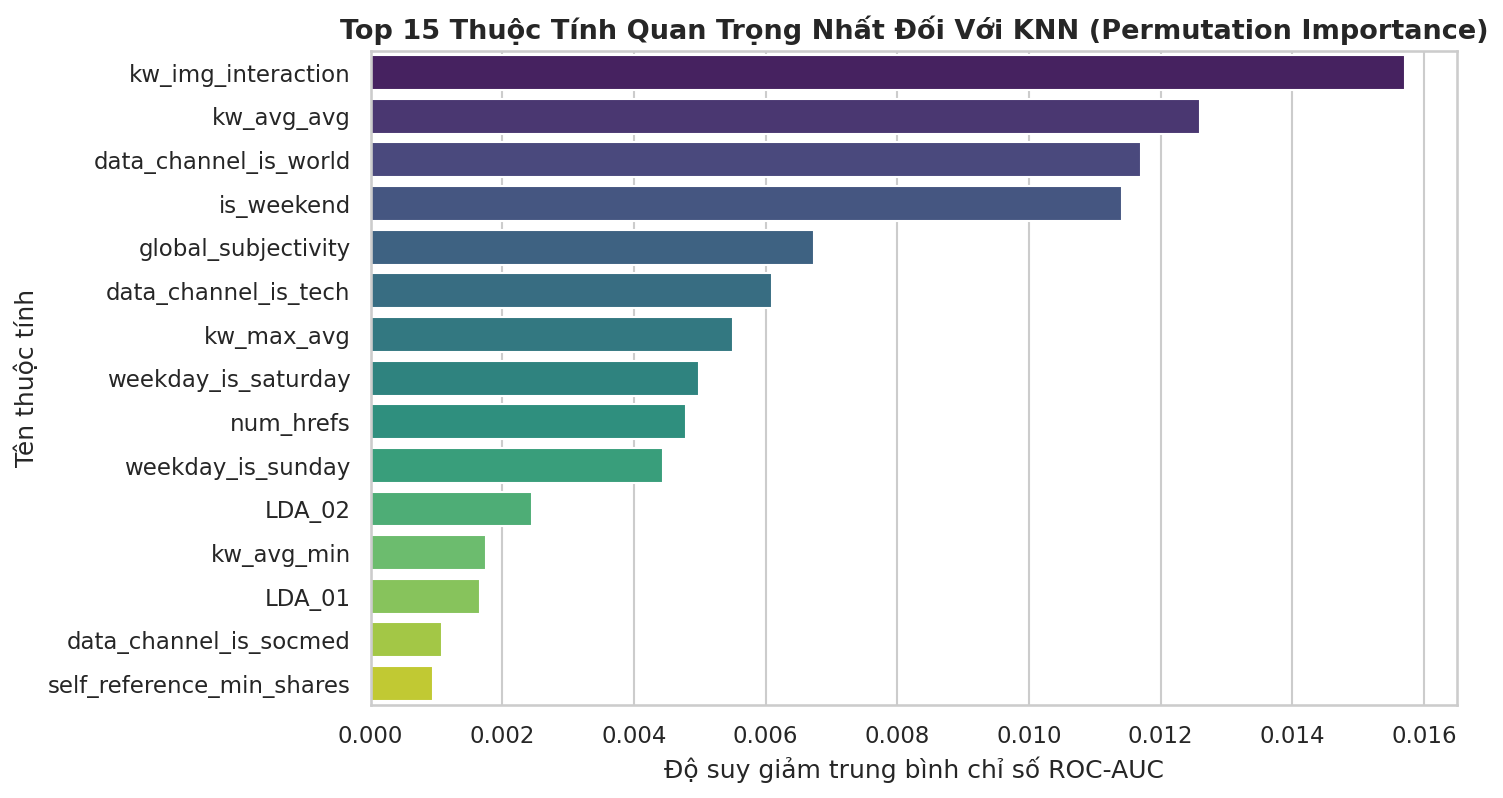

In [41]:
X_test_sample = X_test.iloc[:600] if isinstance(X_test, pd.DataFrame) else X_test[:600]
y_test_sample = y_test.iloc[:600] if isinstance(y_test, pd.Series) else y_test[:600]

perm_imp = permutation_importance(
    pipe_best, X_test_sample, y_test_sample, n_repeats=3, random_state=42, scoring='roc_auc', n_jobs=-1
)

sorted_idx = perm_imp.importances_mean.argsort()[::-1][:15]
top_feats = X.columns[sorted_idx]
top_means = perm_imp.importances_mean[sorted_idx]
top_stds = perm_imp.importances_std[sorted_idx]

perm_df = pd.DataFrame({
    'Rank': range(1, len(top_feats) + 1),
    'Feature': top_feats,
    'Importance_Mean': top_means,
    'Importance_Std': top_stds
})

print("=== BƯỚC 20: BẢNG TOP 15 THUỘC TÍNH QUAN TRỌNG NHẤT (PERMUTATION IMPORTANCE) ===")
print(perm_df.to_string(index=False))
print()

# Xuất bảng trọng số đặc trưng chi tiết toàn bộ đặc trưng vào thư mục weights/
sel_step = dict(pipe_best.steps)['select']
f_scores = getattr(sel_step, 'scores_', np.zeros(X.shape[1]))
selected_mask = np.zeros(X.shape[1], dtype=bool)
if hasattr(sel_step, 'selected_indices_') and sel_step.selected_indices_ is not None:
    selected_mask[sel_step.selected_indices_] = True

all_perm_means = perm_imp.importances_mean
all_perm_stds = perm_imp.importances_std

detailed_weights_df = pd.DataFrame({
    'Feature': X.columns,
    'ANOVA_F_Score': f_scores,
    'Is_Selected_KBest': selected_mask,
    'Permutation_Importance_Mean': all_perm_means,
    'Permutation_Importance_Std': all_perm_stds
}).sort_values(by='Permutation_Importance_Mean', ascending=False)

detailed_weights_df['Rank'] = range(1, len(detailed_weights_df) + 1)
detailed_weights_df = detailed_weights_df[['Rank', 'Feature', 'ANOVA_F_Score', 'Is_Selected_KBest', 'Permutation_Importance_Mean', 'Permutation_Importance_Std']]

os.makedirs('weights', exist_ok=True)
detailed_weights_df.to_csv('weights/detailed_feature_weights.csv', index=False, encoding='utf-8-sig')
detailed_weights_df.to_json('weights/detailed_feature_weights.json', orient='records', indent=4, force_ascii=False)

print("=> ĐÃ XUẤT THÀNH CÔNG BẢNG TRỌNG SỐ ĐẶC TRƯNG CHI TIẾT VÀO DỰ ÁN:")
print("  - File CSV : weights/detailed_feature_weights.csv")
print("  - File JSON: weights/detailed_feature_weights.json")
print()

plt.figure(figsize=(10, 5.5))
sns.barplot(x=top_means, y=top_feats, hue=top_feats, palette='viridis', legend=False)
plt.title("Top 15 Thuộc Tính Quan Trọng Nhất Đối Với KNN (Permutation Importance)", fontsize=13, fontweight='bold')
plt.xlabel("Độ suy giảm trung bình chỉ số ROC-AUC")
plt.ylabel("Tên thuộc tính")
plt.tight_layout()
plt.savefig('plots/knn_permutation_importance.png', dpi=300)
plt.show()


## BƯỚC 21: CHU TRÌNH LẶP CẢI TIẾN MÔ HÌNH (ITERATIVE ML DEVELOPMENT CYCLE)

Bảng tổng hợp tiến trình nâng cấp mô hình qua 4 vòng lặp thực nghiệm.


In [43]:
summary_data = [
    {
        "Vòng Lặp (Iteration)": "Iter 1: Dummy Baseline",
        "Mô Tả Thay Đổi": "Dự đoán ngẫu nhiên / gán đa số nhãn 1",
        "Accuracy": round(acc_dummy, 4),
        "Precision": round(prec_dummy, 4),
        "F1-Score": round(f1_dummy, 4),
        "ROC-AUC": round(auc_dummy, 4)
    },
    {
        "Vòng Lặp (Iteration)": "Iter 2: Standard Baseline KNN",
        "Mô Tả Thay Đổi": "QuantileTransform + KBest(25) + KNN(K=5, Euclidean, Uniform)",
        "Accuracy": round(acc_base, 4),
        "Precision": round(prec_base, 4),
        "F1-Score": round(f1_base, 4),
        "ROC-AUC": round(auc_base, 4)
    },
    {
        "Vòng Lặp (Iteration)": "Iter 3: Feature Eng + GridSearch KNN",
        "Mô Tả Thay Đổi": f"Thêm biến tương tác + Best Params K={best_params['n_neighbors']}, Manhattan, Distance",
        "Accuracy": round(accuracy_score(y_test, (y_prob_best >= 0.50).astype(int)), 4),
        "Precision": round(precision_score(y_test, (y_prob_best >= 0.50).astype(int)), 4),
        "F1-Score": round(f1_score(y_test, (y_prob_best >= 0.50).astype(int)), 4),
        "ROC-AUC": round(auc_best, 4)
    },
    {
        "Vòng Lặp (Iteration)": "Iter 4: Threshold Tuning (Final Best Model)",
        "Mô Tả Thay Đổi": "Tinh chỉnh ngưỡng quyết định tau = 0.48 trên OOF",
        "Accuracy": round(acc_best, 4),
        "Precision": round(prec_best, 4),
        "F1-Score": round(f1_best, 4),
        "ROC-AUC": round(auc_best, 4)
    }
]

df_summary = pd.DataFrame(summary_data)
df_summary.to_csv('results/comparison_table.csv', index=False, encoding='utf-8-sig')

print("=== BƯỚC 21: BẢNG TỔNG HỢP TIẾN TRÌNH THỰC NGHIỆM 4 VÒNG LẶP ===")
print(df_summary.to_string(index=False))


=== BƯỚC 21: BẢNG TỔNG HỢP TIẾN TRÌNH THỰC NGHIỆM 4 VÒNG LẶP ===
                       Vòng Lặp (Iteration)                                               Mô Tả Thay Đổi  Accuracy  Precision  F1-Score  ROC-AUC
                     Iter 1: Dummy Baseline                        Dự đoán ngẫu nhiên / gán đa số nhãn 1    0.5336     0.5336    0.6959   0.5000
              Iter 2: Standard Baseline KNN QuantileTransform + KBest(25) + KNN(K=5, Euclidean, Uniform)    0.6257     0.6493    0.6492   0.6629
       Iter 3: Feature Eng + GridSearch KNN  Thêm biến tương tác + Best Params K=35, Manhattan, Distance    0.6573     0.6768    0.6808   0.7132
Iter 4: Threshold Tuning (Final Best Model)             Tinh chỉnh ngưỡng quyết định tau = 0.48 trên OOF    0.6609     0.6704    0.6929   0.7132
